# ConvNeXt WBC — Clean Pipeline (3-Class)
**Run every cell top-to-bottom. No modifications needed.**

| Step | What happens |
|------|-------------|
| 1 | Install packages + GPU check |
| 2 | Mount Drive, extract zip, load saved splits |
| 3 | Dataset class + weighted sampler |
| 4 | ConvNeXt-Tiny model |
| 5 | Training loop (AMP + early stopping) |
| 6 | 3-Fold cross-validation + OOF predictions |
| 7 | Final model on held-out test set |
| 8 | Results: confusion matrix, F1, accuracy, loss curves |


In [1]:

# ==========================================================
# KAGGLE + IMPORTS
# ==========================================================

import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["OPENCV_LOG_LEVEL"] = "ERROR"
os.environ["PYTHONWARNINGS"] = "ignore"

import cv2
cv2.setNumThreads(0)

import timm
import torch
import random
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)

import albumentations as A
from albumentations.pytorch import ToTensorV2

import torch.nn as nn
from torch.cuda.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", device)

# ==========================================================
# KAGGLE DATASET PATHS
# ==========================================================

BASE_PATH = "/kaggle/input/datasets/lasyapriya16/wbc-bench-2026"

CFG = {

    'phase1_csv': f'{BASE_PATH}/phase1_label.csv',
    'phase2_csv': f'{BASE_PATH}/phase2_train.csv',

    'phase1_img_dir': f'{BASE_PATH}/phase1',
    'phase2_img_dir': f'{BASE_PATH}/phase2/train',

    'output_dir': '/kaggle/working',
    'save_dir': '/kaggle/working/checkpoints',

    'model_name': 'convnext_tiny',
    'img_size': 224,
    'num_classes': 3,

    'batch_size': 32,

    'epochs': 8,
    'decoupled_epochs': 3,

    'lr': 1e-4,
    'decoupled_lr': 1e-5,
    'unfreeze_lr': 5e-6,

    'weight_decay': 1e-4,
    'unfreeze_epoch': 3,

    'n_folds': 3,
    'patience': 3,
    'num_workers': 2
}

os.makedirs(CFG['save_dir'], exist_ok=True)

print("CONFIG LOADED")


DEVICE: cuda
CONFIG LOADED


In [2]:

# ==========================================================
# LOAD CSVS + BUILD 3-CLASS DATAFRAME
# ==========================================================

phase1_df = pd.read_csv(CFG['phase1_csv'])
phase2_df = pd.read_csv(CFG['phase2_csv'])

print("PHASE1:", phase1_df.shape)
print("PHASE2:", phase2_df.shape)

def build_dataframe(df, img_dir):

    temp = df.copy()

    temp['image_path'] = temp['ID'].astype(str).apply(
        lambda x: os.path.join(img_dir, x)
    )

    temp['original_label'] = (
        temp['labels']
        .astype(str)
        .str.strip()
        .str.upper()
    )

    mature_classes = [
        'SNE','LY','MO','BL','EO','BA','BNE','VLY'
    ]

    immature_classes = [
        'MY','MMY','PMY'
    ]

    rare_classes = [
        'PC','PLY'
    ]

    def map_to_3class(label):

        if label in mature_classes:
            return 0

        elif label in immature_classes:
            return 1

        elif label in rare_classes:
            return 2

        else:
            return -1

    temp['label_idx'] = temp['original_label'].apply(
        map_to_3class
    )

    temp = temp[temp['label_idx'] != -1]

    temp['label_idx'] = temp['label_idx'].astype(int)

    return temp[['image_path','label_idx']]

phase1_df = build_dataframe(
    phase1_df,
    CFG['phase1_img_dir']
)

phase2_df = build_dataframe(
    phase2_df,
    CFG['phase2_img_dir']
)

full_df = pd.concat(
    [phase1_df, phase2_df],
    ignore_index=True
)

full_df = full_df.sample(
    frac=1,
    random_state=SEED
).reset_index(drop=True)

print(full_df.shape)

print(full_df['label_idx'].value_counts())

print("FIRST IMAGE EXISTS:")
print(os.path.exists(full_df.iloc[0]['image_path']))


PHASE1: (8288, 6)
PHASE2: (24897, 3)
(33185, 2)
label_idx
0    32050
1     1064
2       71
Name: count, dtype: int64
FIRST IMAGE EXISTS:
True


In [4]:

# ==========================================================
# FAST SAFE DATASET
# ==========================================================

class WBCDataset(Dataset):

    def __init__(self, df, transforms=None):

        self.df = df.reset_index(drop=True)

        self.transforms = transforms

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image_path = row.image_path

        label = int(row.label_idx)

        try:

            image = Image.open(image_path).convert("RGB")

            image = np.array(image)

        except Exception:

            image = np.zeros(
                (
                    CFG['img_size'],
                    CFG['img_size'],
                    3
                ),
                dtype=np.uint8
            )

        try:
            image = extract_roi(image)
        except:
            pass

        try:
            image = denoise_pipeline(image)
        except:
            pass

        if self.transforms:

            image = self.transforms(
                image=image
            )['image']

        return image, label


## Cell 1 — Install packages

In [5]:
!pip install timm scikit-learn matplotlib seaborn -q
!pip install albumentations -q

## Cell 2 — Imports & config

In [2]:
import os, random, warnings, pickle
import numpy as np
import pandas as pd
import cv2
import torch
import timm
import torch.nn as nn
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (classification_report, confusion_matrix,
                              balanced_accuracy_score, f1_score)
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {device}")
if device.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

CFG = {
    'img_size'        : 224,
    'batch_size'      : 32,
    'num_workers'     : 4,
    'pin_memory'      : True,
    'epochs'          : 12,          # was 8 — more epochs, early stopping handles cutoff
    'lr'              : 1e-4,
    'weight_decay'    : 1e-4,
    'unfreeze_epoch'  : 3,
    'unfreeze_lr'     : 5e-6,        # NEW — was lr/5=2e-5, now 5e-6 (more stable)
    'patience'        : 4,           # was 3 — give model more time after unfreeze
    'label_smoothing' : 0.1,         # NEW — reduces overconfidence on augmented Rare
    'model_name'      : 'convnext_tiny',
    'num_classes'     : 3,
    'classes'         : ['Mature', 'Immature', 'Rare'],
    'label_smoothing' : 0.10,     # used by make_criterion in Cell 17
    'unfreeze_lr'     : 5e-6,     # used by run_training in Cell 28
    'n_folds'         : 3,
    'ckpt_dir'        : '/content/checkpoints',
    'save_dir'        : '/content/drive/MyDrive/wbc/checkpoints',
}
os.makedirs(CFG['ckpt_dir'], exist_ok=True)
print("\nCFG ready:", CFG)

# Class index mappings (must match saved CSVs)
IDX2CLASS = {0: 'Mature', 1: 'Immature', 2: 'Rare'}
CLASS2IDX = {v: k for k, v in IDX2CLASS.items()}


Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB

CFG ready: {'img_size': 224, 'batch_size': 32, 'num_workers': 4, 'pin_memory': True, 'epochs': 12, 'lr': 0.0001, 'weight_decay': 0.0001, 'unfreeze_epoch': 3, 'unfreeze_lr': 5e-06, 'patience': 4, 'label_smoothing': 0.1, 'model_name': 'convnext_tiny', 'num_classes': 3, 'classes': ['Mature', 'Immature', 'Rare'], 'n_folds': 3, 'ckpt_dir': '/content/checkpoints', 'save_dir': '/content/drive/MyDrive/wbc/checkpoints'}


## Cell 3 — Mount Drive & load pre-saved splits

Your splits are already saved at `MyDrive/wbc/checkpoints/` from the previous session. We load them directly — no re-processing needed.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/wbc/checkpoints'

# Load the pre-saved split CSVs
train_df = pd.read_csv(f'{SAVE_DIR}/train_df.csv')
val_df   = pd.read_csv(f'{SAVE_DIR}/val_df.csv')
test_df  = pd.read_csv(f'{SAVE_DIR}/test_df.csv')

# Rename label column to standard name if needed
# The saved CSV uses 'label3' and 'label3_idx' columns
if 'label3' in train_df.columns and 'label' not in train_df.columns:
    train_df['label']     = train_df['label3']
    val_df['label']       = val_df['label3']
    test_df['label']      = test_df['label3']
if 'label3_idx' in train_df.columns and 'label_idx' not in train_df.columns:
    train_df['label_idx'] = train_df['label3_idx'].astype(int)
    val_df['label_idx']   = val_df['label3_idx'].astype(int)
    test_df['label_idx']  = test_df['label3_idx'].astype(int)

# Drop any rows where path is missing
for df in [train_df, val_df, test_df]:
    df.dropna(subset=['path','label','label_idx'], inplace=True)
    df.reset_index(drop=True, inplace=True)

print(f"train_df : {len(train_df):,} rows")
print(f"val_df   : {len(val_df):,} rows")
print(f"test_df  : {len(test_df):,} rows")
print()
print("Class distribution (train):")
print(train_df['label'].value_counts().to_string())
print()
print("Columns available:", train_df.columns.tolist())


Mounted at /content/drive
train_df : 21,172 rows
val_df   : 4,537 rows
test_df  : 4,538 rows

Class distribution (train):
label
Mature      20422
Immature      680
Rare           70

Columns available: ['ID', 'labels', 'split', 'phase', 'path', 'label3', 'label3_idx', 'label', 'label_idx']


## Cell 4 — Fix image paths

The CSVs contain Drive paths. We re-point them to `/content/wbc` (local SSD) which is 10x faster for training.

In [4]:
import zipfile

# Extract zip to local SSD if not already done
ZIP_PATH   = '/content/drive/MyDrive/wbc-bench-2026.zip'
LOCAL_ROOT = '/content/wbc'

if not os.path.exists(LOCAL_ROOT) or len(os.listdir(LOCAL_ROOT)) < 3:
    print("Extracting zip to local SSD (faster I/O during training)...")
    os.makedirs(LOCAL_ROOT, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(LOCAL_ROOT)
    print("Done.")
else:
    print("Already extracted.")

print("Local contents:", os.listdir(LOCAL_ROOT))

# ── Remap paths from Drive to local SSD ──────────────────────────────────
def remap_path(p):
    """Replace Drive prefix with local SSD path."""
    # Handle both possible Drive locations
    for prefix in [
        '/content/drive/MyDrive/wbc',
        '/content/drive/My Drive/wbc',
    ]:
        if isinstance(p, str) and p.startswith(prefix):
            return p.replace(prefix, LOCAL_ROOT)
    return p

train_df['path'] = train_df['path'].apply(remap_path)
val_df['path']   = val_df['path'].apply(remap_path)
test_df['path']  = test_df['path'].apply(remap_path)

# Verify
n_ok  = train_df['path'].apply(os.path.isfile).sum()
n_bad = len(train_df) - n_ok
print(f"\nTrain paths: {n_ok:,} exist, {n_bad:,} missing")
if n_bad > 0:
    print("Sample missing:", train_df[~train_df['path'].apply(os.path.isfile)]['path'].iloc[0])

# Drop missing (should be 0 if paths are correct)
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    before = len(df)
    mask = df['path'].apply(os.path.isfile)
    df.drop(df[~mask].index, inplace=True)
    df.reset_index(drop=True, inplace=True)
    if before - len(df) > 0:
        print(f"Dropped {before-len(df)} missing from {name}_df")

print(f"\nFinal counts — train:{len(train_df)}, val:{len(val_df)}, test:{len(test_df)}")


Extracting zip to local SSD (faster I/O during training)...
Done.
Local contents: ['phase2_train.csv', 'phase1', 'phase2_eval.csv', 'phase1_label.csv', 'phase2', 'phase2_test.csv']

Train paths: 21,172 exist, 0 missing

Final counts — train:21172, val:4537, test:4538


Apply ROI cropping to extract nucleus region.

In [7]:

import cv2
import numpy as np

def crop_wbc_roi(img_bgr, margin=0.35):
    """
    Detects WBC nucleus via cascade of colour-space masks and returns
    a square crop centred on it.

    Parameters
    ----------
    img_bgr : np.ndarray  BGR image from cv2.imread
    margin  : float       fractional padding around detected nucleus (0.35 = 35%)

    Returns
    -------
    np.ndarray  Cropped BGR image, always non-empty
    """
    if img_bgr is None or img_bgr.size == 0:
        return img_bgr

    h, w = img_bgr.shape[:2]
    img_area = h * w

    # ── Helper: given a binary mask, find best bounding box ───────
    def mask_to_crop(mask):
        """
        From a binary mask, find the largest blob that could be a
        WBC nucleus (area between 3% and 55% of image).
        Returns (x1,y1,x2,y2) or None if nothing found.
        """
        # Clean up mask
        k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=3)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  k, iterations=2)

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return None

        # Filter by area only — NO circularity filter
        # (lobed neutrophils, blasts etc. are NOT circular)
        valid = [c for c in contours
                 if img_area * 0.03 <= cv2.contourArea(c) <= img_area * 0.55]
        if not valid:
            return None

        c = max(valid, key=cv2.contourArea)
        x, y, bw, bh = cv2.boundingRect(c)

        # Add margin
        pad_x = int(bw * margin)
        pad_y = int(bh * margin)
        x1 = max(0, x - pad_x)
        y1 = max(0, y - pad_y)
        x2 = min(w, x + bw + pad_x)
        y2 = min(h, y + bh + pad_y)

        # Make square
        side = max(x2 - x1, y2 - y1)
        cx   = (x1 + x2) // 2
        cy   = (y1 + y2) // 2
        x1   = max(0, cx - side // 2)
        y1   = max(0, cy - side // 2)
        x2   = min(w, x1 + side)
        y2   = min(h, y1 + side)

        return (x1, y1, x2, y2)

    def apply_crop(bbox):
        x1, y1, x2, y2 = bbox
        crop = img_bgr[y1:y2, x1:x2]
        if crop.size > 0 and crop.shape[0] > 30 and crop.shape[1] > 30:
            return crop
        return None


    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Purple-violet hue range (OpenCV hue 0-180, so 120-165 = 240-330°)
    mask_hsv = cv2.inRange(hsv,
                           np.array([110, 40, 30],  dtype=np.uint8),
                           np.array([165, 255, 220], dtype=np.uint8))

    bbox = mask_to_crop(mask_hsv)
    if bbox:
        crop = apply_crop(bbox)
        if crop is not None:
            return crop


    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l_ch, a_ch, b_ch = cv2.split(lab)

    # b* < 127 in uint8 LAB = negative b* = blue/purple tones
    # We threshold at 118 (gives ~9 units below neutral=128)
    _, mask_lab = cv2.threshold(b_ch, 118, 255, cv2.THRESH_BINARY_INV)

    # Also gate on a* > 128: purple has positive a* (red-green axis)
    # This removes blue artefacts (which have negative a*)
    _, mask_a = cv2.threshold(a_ch, 128, 255, cv2.THRESH_BINARY)
    mask_lab  = cv2.bitwise_and(mask_lab, mask_a)

    bbox = mask_to_crop(mask_lab)
    if bbox:
        crop = apply_crop(bbox)
        if crop is not None:
            return crop

    sat  = hsv[:, :, 1]
    val  = hsv[:, :, 2]
    mask_sat  = ((sat > 50) & (val < 210)).astype(np.uint8) * 255

    bbox = mask_to_crop(mask_sat)
    if bbox:
        crop = apply_crop(bbox)
        if crop is not None:
            return crop


    side = int(min(h, w) * 0.80)
    cx, cy = w // 2, h // 2
    x1 = max(0, cx - side // 2)
    y1 = max(0, cy - side // 2)
    x2 = min(w, x1 + side)
    y2 = min(h, y1 + side)
    return img_bgr[y1:y2, x1:x2]


print("Testing fixed ROI crop on 3 samples...")
for i in range(min(3, len(train_df))):
    _path = train_df['path'].iloc[i]
    _lbl  = train_df['label'].iloc[i]
    _img  = cv2.imread(_path)
    if _img is not None:
        _den  = denoise_wbc(_img)
        _crop = crop_wbc_roi(_den)
        print(f"  [{_lbl}] original={_img.shape[:2]}  crop={_crop.shape[:2]}")
    else:
        print(f"  [{_lbl}] could not read image")

print("\nFixed ROI cropping ready.")
print("Changes from previous version:")
print("  ✓ REMOVED Otsu dark-mask  (was grabbing RBCs)")
print("  ✓ REMOVED circularity filter (was rejecting lobed nuclei)")
print("  ✓ ADDED LAB b*-channel mask (best separator: purple vs pink RBCs)")
print("  ✓ ADDED saturation mask as 3rd fallback")
print("  ✓ Cascade: HSV → LAB → Saturation → Centre crop")

Testing fixed ROI crop on 3 samples...
  [Mature] original=(368, 368)  crop=(225, 225)
  [Mature] original=(370, 368)  crop=(249, 249)
  [Mature] original=(370, 368)  crop=(167, 167)

Fixed ROI cropping ready.
Changes from previous version:
  ✓ REMOVED Otsu dark-mask  (was grabbing RBCs)
  ✓ REMOVED circularity filter (was rejecting lobed nuclei)
  ✓ ADDED LAB b*-channel mask (best separator: purple vs pink RBCs)
  ✓ ADDED saturation mask as 3rd fallback
  ✓ Cascade: HSV → LAB → Saturation → Centre crop


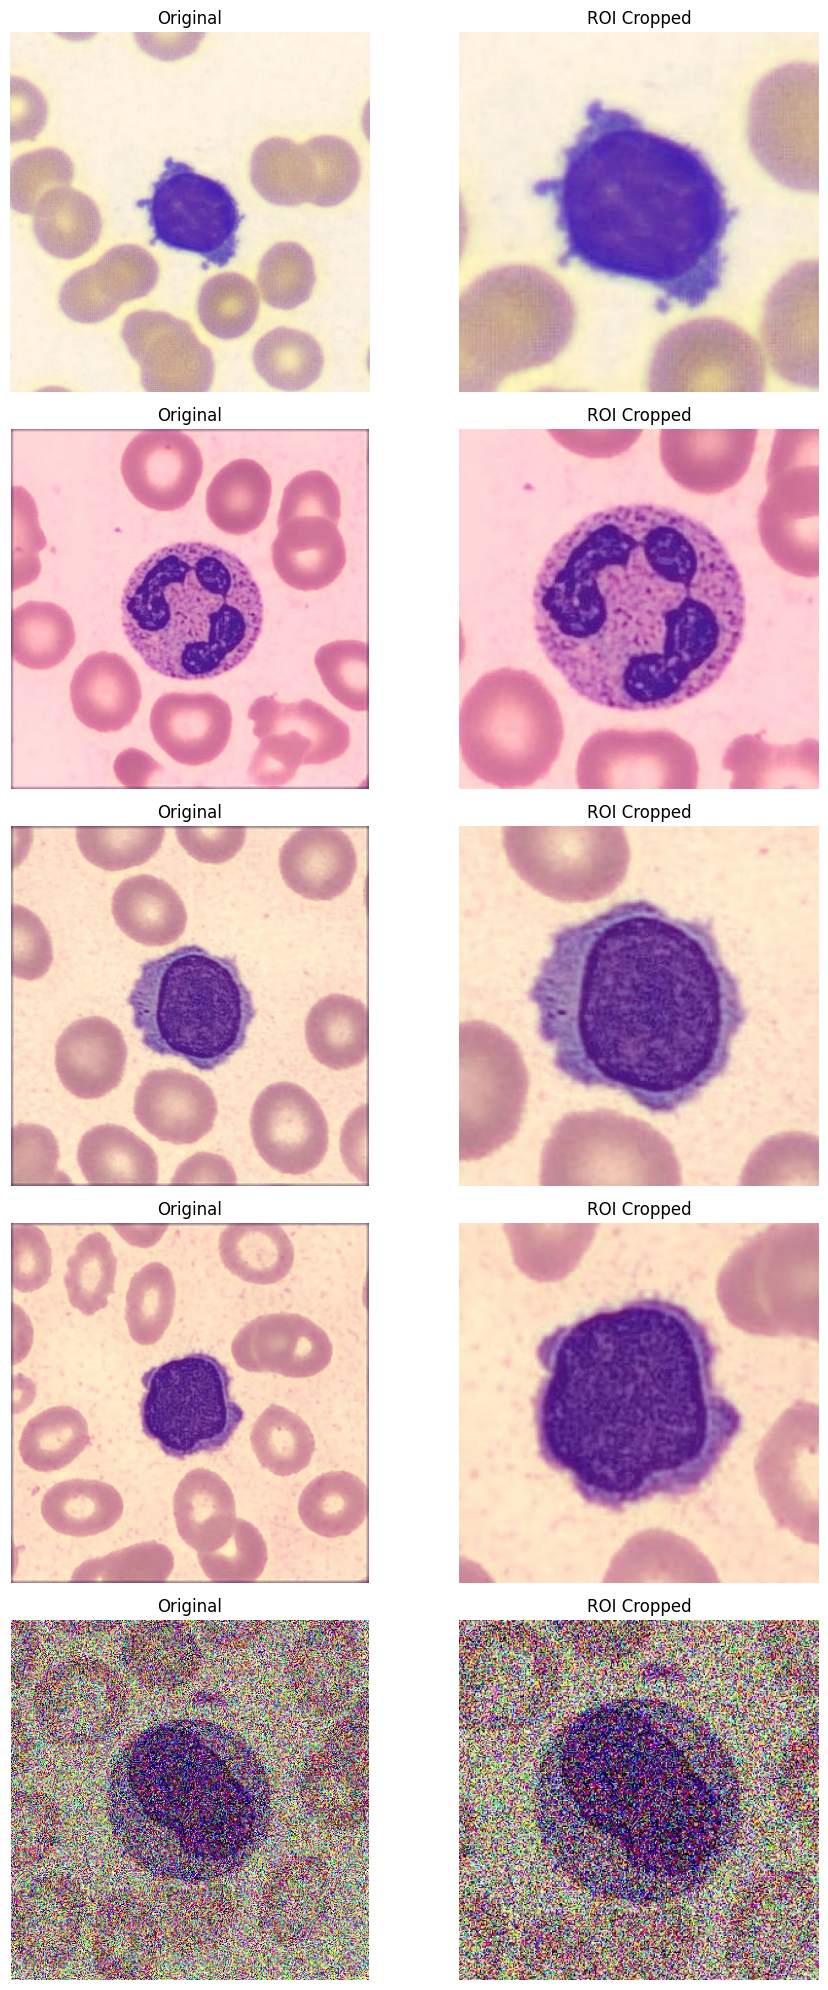

In [8]:
import matplotlib.pyplot as plt
import cv2

def show_roi_samples(df, num_samples=5):
    samples = df.sample(num_samples).reset_index(drop=True)

    plt.figure(figsize=(10, 4 * num_samples))

    valid_count = 0

    for i in range(num_samples):
        path = samples.loc[i, 'path']

        img = cv2.imread(path)

        #  FIX 1: Check if image loaded
        if img is None:
            print(f"Skipping (cannot read): {path}")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        crop = crop_wbc_roi(img)
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)

        # Original
        plt.subplot(num_samples, 2, 2*i + 1)
        plt.imshow(img_rgb)
        plt.title("Original")
        plt.axis("off")

        # Cropped
        plt.subplot(num_samples, 2, 2*i + 2)
        plt.imshow(crop_rgb)
        plt.title("ROI Cropped")
        plt.axis("off")

        valid_count += 1

    if valid_count == 0:
        print("No valid images to display. Check paths.")
        return

    plt.tight_layout()
    plt.show()


#  FORCE DISPLAY IN COLAB
%matplotlib inline

# RUN
show_roi_samples(train_df, num_samples=5)

In [6]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ─────────────────────────────────────────────────────────────────
# Core denoising function
# ─────────────────────────────────────────────────────────────────
def denoise_wbc(img_bgr):
    """
    Multi-stage noise removal tuned for WBC microscopy images.

    Stage 1 — Gaussian Blur (sigma=0.8, kernel 3×3)
        Removes high-frequency JPEG/sensor noise without
        blurring nucleus edges significantly.

    Stage 2 — Bilateral Filter (d=9, sigmaColor=35, sigmaSpace=20)
        Edge-preserving smoothing: flattens flat background regions
        and cytoplasm while keeping nucleus/granule boundaries sharp.
        sigmaColor=35 is deliberately moderate so stain colour
        variation is preserved (important for Rare class detection).

    Stage 3 — CLAHE on L-channel (clipLimit=2.0, tileGrid=8×8)
        Adaptive histogram equalisation in LAB space.
        Boosts local contrast so nucleus stands out from cytoplasm,
        making HSV thresholding in crop_wbc_roi() more reliable.

    Parameters
    ----------
    img_bgr : np.ndarray  BGR image (as returned by cv2.imread)

    Returns
    -------
    np.ndarray  Denoised BGR image, same dtype/shape as input
    """
    if img_bgr is None or img_bgr.size == 0:
        return img_bgr

    # ── Stage 1: Mild Gaussian blur ───────────────────────────────
    denoised = cv2.GaussianBlur(img_bgr, (3, 3), sigmaX=0.8)

    # ── Stage 2: Bilateral filter (edge-preserving) ───────────────
    # NOTE: bilateral filter is slow on large images; we apply on
    # the full image here (before crop) so the background is also
    # cleaned — this improves HSV masking inside crop_wbc_roi().
    denoised = cv2.bilateralFilter(
        denoised,
        d          = 9,    # neighbourhood diameter
        sigmaColor = 35,   # colour similarity range
        sigmaSpace = 20    # spatial range
    )

    # ── Stage 3: CLAHE on L-channel (LAB colour space) ───────────
    lab        = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b    = cv2.split(lab)
    clahe      = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq       = clahe.apply(l)
    lab_eq     = cv2.merge([l_eq, a, b])
    denoised   = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)

    return denoised


# ─────────────────────────────────────────────────────────────────
# Before / After visualisation
# Shows 5 samples (one per row) — picks from each class if possible
# ─────────────────────────────────────────────────────────────────
def visualize_denoising(df, n_samples=5, save_dir=None):
    """
    Plots a grid of:
      Col 1 — Original image
      Col 2 — After denoising
      Col 3 — After denoising + ROI crop
      Col 4 — Pixel-difference heatmap (Original vs Denoised)

    Samples are drawn to cover all available classes.
    """
    # Try to pick samples that cover all classes
    sampled_rows = []
    for label in df['label'].unique():
        sub = df[df['label'] == label]
        sampled_rows.append(sub.sample(min(2, len(sub)),
                                       random_state=SEED))
    sample_df = pd.concat(sampled_rows).head(n_samples).reset_index(drop=True)

    n_cols  = 4
    n_rows  = len(sample_df)
    fig     = plt.figure(figsize=(5 * n_cols, 4.2 * n_rows))
    gs      = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                                hspace=0.35, wspace=0.08)

    col_titles = ['Original', 'Denoised', 'Denoised + ROI Crop',
                  'Noise Map (diff × 5)']

    for row_i, (_, row) in enumerate(sample_df.iterrows()):

        img_bgr = cv2.imread(row['path'])
        if img_bgr is None:
            continue

        den_bgr  = denoise_wbc(img_bgr)
        crop_bgr = crop_wbc_roi(den_bgr)   # crop AFTER denoise

        # Convert to RGB for matplotlib
        orig_rgb  = cv2.cvtColor(img_bgr,  cv2.COLOR_BGR2RGB)
        den_rgb   = cv2.cvtColor(den_bgr,  cv2.COLOR_BGR2RGB)
        crop_rgb  = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)

        # Difference map — amplify x5 so subtle noise is visible
        diff = cv2.absdiff(orig_rgb.astype(np.int16),
                           den_rgb.astype(np.int16))
        diff = np.clip(diff * 5, 0, 255).astype(np.uint8)
        diff_gray = cv2.cvtColor(diff, cv2.COLOR_RGB2GRAY)

        images   = [orig_rgb, den_rgb, crop_rgb, diff_gray]
        cmaps    = ['viridis' if j == 3 else None for j in range(4)]
        label_str = f"[{row['label']}]  {os.path.basename(row['path'])}"

        for col_i, (im, cmap) in enumerate(zip(images, cmaps)):
            ax = fig.add_subplot(gs[row_i, col_i])
            ax.imshow(im, cmap=cmap)
            ax.axis('off')

            # Column headers on first row only
            if row_i == 0:
                ax.set_title(col_titles[col_i], fontsize=11,
                             fontweight='bold', pad=6)

            # Row label on first column only
            if col_i == 0:
                ax.set_ylabel(label_str, fontsize=7.5,
                              rotation=0, labelpad=4,
                              ha='right', va='center')

    fig.suptitle(
        'WBC Noise Removal — Before / After\n'
        '(Gaussian → Bilateral → CLAHE)',
        fontsize=14, fontweight='bold', y=1.01
    )

    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        out_path = os.path.join(save_dir, 'denoise_before_after.png')
        plt.savefig(out_path, dpi=130, bbox_inches='tight')
        print(f"Plot saved → {out_path}")

    plt.show()
    plt.close(fig)


# ─────────────────────────────────────────────────────────────────
# Run visualisation — show before/after for 5 sample images
# ─────────────────────────────────────────────────────────────────
print("Running noise removal visualisation on sample images...")
visualize_denoising(
    train_df,
    n_samples = 5,
    save_dir  = CFG['save_dir']   # saves to Drive automatically
)
print("Denoising function ready — will be applied inside Dataset.__getitem__()")

Running noise removal visualisation on sample images...
Plot saved → /content/drive/MyDrive/wbc/checkpoints/denoise_before_after.png
Denoising function ready — will be applied inside Dataset.__getitem__()


## Cell 5 — Transforms

In [9]:
# ══════════════════════════════════════════════════════════════════
# Cell 5 — Transforms
# ══════════════════════════════════════════════════════════════════
from torchvision import transforms

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
SZ   = CFG['img_size']   # 224

# Standard train augmentation
train_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((SZ, SZ)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# Stronger augmentation for Rare class (very few samples)
rare_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((SZ, SZ)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(brightness=0.5, contrast=0.5,
                           saturation=0.4, hue=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.15, 0.15),
                            scale=(0.80, 1.20)),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# No augmentation for val/test
val_tf = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((SZ, SZ)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

print("train_tf defined:", train_tf is not None)
print("rare_tf  defined:", rare_tf  is not None)
print("val_tf   defined:", val_tf   is not None)
print("Transforms ready.")

train_tf defined: True
rare_tf  defined: True
val_tf   defined: True
Transforms ready.


In [10]:

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset

class WBCDataset(Dataset):
    """
    Loads WBC images on-the-fly.
    Pipeline per image:
        Load → Denoise → ROI Crop → Convert RGB → Augment → Normalise
    """
    def __init__(self, df, mode='train'):
        self.df   = df.reset_index(drop=True)
        self.mode = mode   # 'train', 'val', 'test'

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ── Step 1: Load ──────────────────────────────────────────
        img_bgr = cv2.imread(row['path'])
        if img_bgr is None:
            # Return blank image if file missing — avoids crash
            img_bgr = np.zeros((SZ, SZ, 3), dtype=np.uint8)

        # ── Step 2: Denoise (BEFORE crop) ─────────────────────────
        img_bgr = denoise_wbc(img_bgr)

        # ── Step 3: ROI Crop ──────────────────────────────────────
        img_bgr = crop_wbc_roi(img_bgr)

        # ── Step 4: Convert BGR → RGB ─────────────────────────────
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        # ── Step 5: Augment + Normalise ───────────────────────────
        if self.mode == 'train':
            if row['label'] == 'Rare':
                tensor = rare_tf(img_rgb)
            else:
                tensor = train_tf(img_rgb)
        else:
            tensor = val_tf(img_rgb)

        label = torch.tensor(int(row['label_idx']), dtype=torch.long)
        return tensor, label


# ── Sanity check ──────────────────────────────────────────────────
print("Checking all dependencies before Dataset test...")
print(f"  train_tf : {'OK' if 'train_tf' in dir() else 'MISSING — run Cell 5 first'}")
print(f"  rare_tf  : {'OK' if 'rare_tf'  in dir() else 'MISSING — run Cell 5 first'}")
print(f"  val_tf   : {'OK' if 'val_tf'   in dir() else 'MISSING — run Cell 5 first'}")
print(f"  SZ       : {SZ}")

ds       = WBCDataset(train_df.head(4), mode='train')
img, lbl = ds[0]
print(f"\nImage shape : {img.shape}")
print(f"Label       : {lbl.item()} ({IDX2CLASS[lbl.item()]})")
print(f"Pixel range : [{img.min():.2f}, {img.max():.2f}]")
print("Dataset class OK — pipeline: Load → Denoise → Crop → Augment")

Checking all dependencies before Dataset test...
  train_tf : OK
  rare_tf  : OK
  val_tf   : OK
  SZ       : 224

Image shape : torch.Size([3, 224, 224])
Label       : 0 (Mature)
Pixel range : [-2.12, 1.76]
Dataset class OK — pipeline: Load → Denoise → Crop → Augment


Step 1: Augmentation preview (should look like DenseNet output)


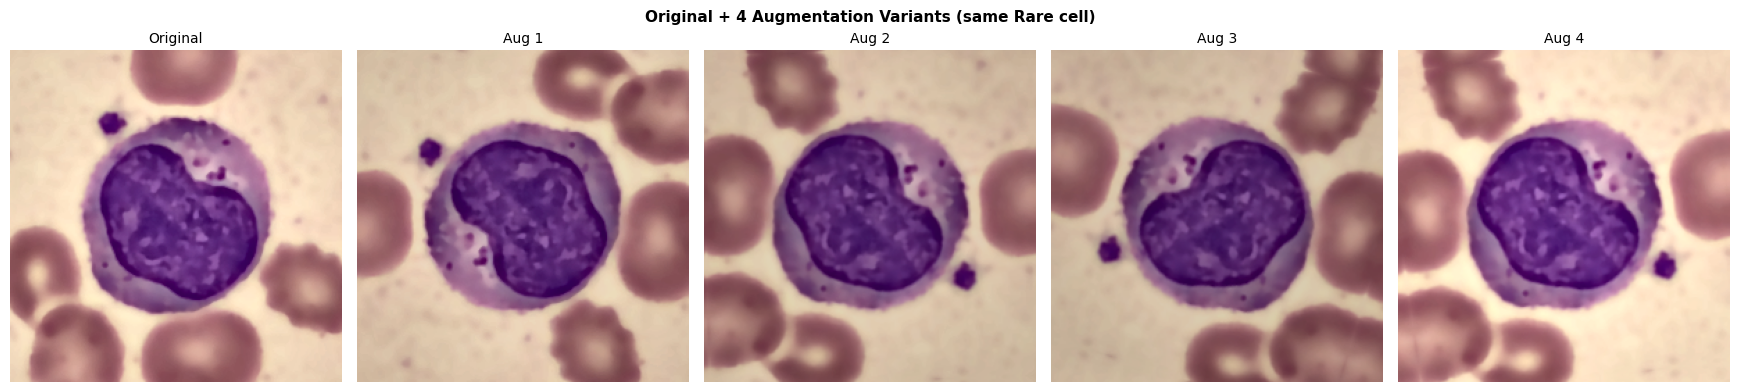

Preview saved → /content/drive/MyDrive/wbc/checkpoints/rare_aug_preview.png

Step 2: Generating offline augmented images to disk...
Rare class : 70 original → target 500
Generating : 430 synthetic images
Valid source images : 70 / 70  (0 skipped — bad crop or missing)

Class distribution after augmentation:
label
Mature      20422
Immature      680
Rare          500

Cell 5.5 complete.


In [11]:

import cv2
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt

RARE_TARGET  = 500
AUG_SAVE_DIR = '/content/wbc_rare_aug'
os.makedirs(AUG_SAVE_DIR, exist_ok=True)

# ── Single augmentation function (matches DenseNet style exactly) ─
def augment_rare_image(img_rgb):
    """
    Conservative augmentation on float32 [0,1] RGB image.
    Identical philosophy to your working DenseNet augment_image():
      - Random horizontal flip
      - Random vertical flip
      - Random 90° rotation (0/90/180/270)
      - Mild brightness jitter ×0.85-1.15
    No elastic distortion, no noise, no hue, no black borders.
    """
    img = img_rgb.astype(np.float32) / 255.0

    # Horizontal flip
    if np.random.rand() < 0.5:
        img = np.fliplr(img)

    # Vertical flip
    if np.random.rand() < 0.5:
        img = np.flipud(img)

    # 90° rotation (0, 90, 180, 270)
    img = np.rot90(img, np.random.randint(0, 4))

    # Mild rotation ±20° with reflect border (no black corners)
    angle  = np.random.uniform(-20, 20)
    h, w   = img.shape[:2]
    M      = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img_u8 = (np.clip(img, 0, 1) * 255).astype(np.uint8)
    img_u8 = cv2.warpAffine(img_u8, M, (w, h),
                             borderMode=cv2.BORDER_REFLECT_101)
    img    = img_u8.astype(np.float32) / 255.0

    # Brightness jitter (same range as your DenseNet: 0.8-1.2)
    img = np.clip(img * np.random.uniform(0.85, 1.15), 0.0, 1.0)

    return (img * 255).astype(np.uint8)


def load_and_prepare(path):
    """
    Load → Denoise → ROI Crop → RGB.
    Returns None if image is bad/has black borders.
    """
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        return None

    img_bgr = denoise_wbc(img_bgr)
    img_bgr = crop_wbc_roi(img_bgr)

    # Reject if too many black pixels (failed crop)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    if np.sum(gray < 15) / gray.size > 0.08:
        return None

    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


# ── Visual check: exactly like your DenseNet plot ─────────────────
def show_augmentation_preview(train_df, n_aug=4):
    """
    Shows 1 Rare sample + n_aug augmented variants side by side.
    Matches your DenseNet 'Original + 4 Augmentation Variants' plot.
    """
    rare_df = train_df[train_df['label'] == 'Rare'].reset_index(drop=True)

    # Find first valid Rare image
    orig_rgb = None
    for _, row in rare_df.iterrows():
        orig_rgb = load_and_prepare(row['path'])
        if orig_rgb is not None:
            break

    if orig_rgb is None:
        print("No valid Rare image found for preview.")
        return

    fig, axes = plt.subplots(1, n_aug + 1, figsize=(3.5 * (n_aug + 1), 4))
    fig.suptitle(f'Original + {n_aug} Augmentation Variants (same Rare cell)',
                 fontsize=11, fontweight='bold')

    axes[0].imshow(orig_rgb)
    axes[0].set_title('Original', fontsize=10)
    axes[0].axis('off')

    for i in range(1, n_aug + 1):
        aug = augment_rare_image(orig_rgb.copy())
        axes[i].imshow(aug)
        axes[i].set_title(f'Aug {i}', fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    out = os.path.join(CFG['save_dir'], 'rare_aug_preview.png')
    plt.savefig(out, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"Preview saved → {out}")


# ── Offline augmentation (generates files to disk) ────────────────
def augment_rare_class(train_df, target_count=RARE_TARGET,
                       save_dir=AUG_SAVE_DIR):
    """
    Generates synthetic Rare images until target_count is reached.
    Only uses clean source images (no black border artifacts).
    """
    rare_df  = train_df[train_df['label'] == 'Rare'].copy()
    n_have   = len(rare_df)
    n_needed = max(0, target_count - n_have)

    print(f"Rare class : {n_have} original → target {target_count}")
    print(f"Generating : {n_needed} synthetic images")

    if n_needed == 0:
        print("Already have enough — skipping.")
        return train_df

    # Pre-load and validate all good source images
    good = []
    skipped = 0
    for _, row in rare_df.iterrows():
        img_rgb = load_and_prepare(row['path'])
        if img_rgb is not None:
            good.append((row, img_rgb))
        else:
            skipped += 1

    print(f"Valid source images : {len(good)} / {n_have}  "
          f"({skipped} skipped — bad crop or missing)")

    if not good:
        print("ERROR: No valid Rare source images. Check ROI crop.")
        return train_df

    new_rows = []
    gen_idx  = 0

    while gen_idx < n_needed:
        for row, img_rgb in good:
            if gen_idx >= n_needed:
                break

            aug_rgb = augment_rare_image(img_rgb.copy())
            aug_bgr = cv2.cvtColor(aug_rgb, cv2.COLOR_RGB2BGR)

            # Reject if augmentation somehow introduced black borders
            gray = cv2.cvtColor(aug_bgr, cv2.COLOR_BGR2GRAY)
            if np.sum(gray < 15) / gray.size > 0.05:
                continue

            fname = f"rare_aug_{gen_idx:05d}.png"
            fpath = os.path.join(save_dir, fname)
            cv2.imwrite(fpath, aug_bgr)

            new_rows.append({
                'path'      : fpath,
                'label'     : 'Rare',
                'label_idx' : int(row['label_idx']),
                **{c: row[c] for c in row.index
                   if c not in ('path', 'label', 'label_idx')}
            })
            gen_idx += 1

    aug_df       = pd.DataFrame(new_rows)
    train_df_aug = pd.concat([train_df, aug_df], ignore_index=True)
    train_df_aug = train_df_aug.sample(frac=1,
                                       random_state=SEED).reset_index(drop=True)

    print(f"\nClass distribution after augmentation:")
    print(train_df_aug['label'].value_counts().to_string())
    return train_df_aug


# ── Run preview first so you can verify quality ───────────────────
print("=" * 55)
print("Step 1: Augmentation preview (should look like DenseNet output)")
print("=" * 55)
show_augmentation_preview(train_df, n_aug=4)

print("\n" + "=" * 55)
print("Step 2: Generating offline augmented images to disk...")
print("=" * 55)
train_df = augment_rare_class(train_df, target_count=RARE_TARGET)
print("\nCell 5.5 complete.")

In [12]:


class FocalLoss(nn.Module):
    """
    Focal Loss for multi-class classification.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Parameters
    ----------
    gamma       : float   focusing parameter (0 = standard CE, 2 is typical)
    alpha       : Tensor  per-class weights (same as class_weight in CE).
                          Pass get_class_weights(df) here.
    reduction   : str     'mean' | 'sum' | 'none'
    """
    def __init__(self, gamma=2.0, alpha=None, reduction='mean'):
        super().__init__()
        self.gamma     = gamma
        self.alpha     = alpha   # 1-D tensor of length num_classes
        self.reduction = reduction

    def forward(self, logits, targets):
        """
        logits  : (N, C)  raw model outputs (NOT softmaxed)
        targets : (N,)    integer class indices
        """
        log_probs = nn.functional.log_softmax(logits, dim=1)          # (N, C)
        probs     = log_probs.exp()                                    # (N, C)

        # Gather the log-prob and prob for the true class
        log_pt = log_probs.gather(1, targets.unsqueeze(1)).squeeze(1)  # (N,)
        pt     = probs.gather(1, targets.unsqueeze(1)).squeeze(1)      # (N,)

        focal_weight = (1.0 - pt) ** self.gamma                       # (N,)
        loss         = -focal_weight * log_pt                          # (N,)

        # Apply per-class alpha weights
        if self.alpha is not None:
            alpha_t = self.alpha.to(logits.device)[targets]            # (N,)
            loss    = alpha_t * loss

        if self.reduction == 'mean':
            return loss.mean()
        elif self.reduction == 'sum':
            return loss.sum()
        return loss


# ══════════════════════════════════════════════════════════════════
# REPLACE make_criterion() in Cell 5.6 — adds label_smoothing
# ══════════════════════════════════════════════════════════════════

def make_criterion(df, gamma=2.0):
    """
    FocalLoss with class weights + label smoothing.
    Label smoothing 0.1 prevents overconfidence on augmented Rare images.
    This is the primary fix for OOF=0.77 → Test=0.21 Rare gap.
    """
    y = df['label_idx'].values.astype(int)
    w = compute_class_weight('balanced', classes=np.unique(y), y=y)
    alpha = torch.tensor(w, dtype=torch.float).to(device)
    print(f"  Criterion alpha (class weights): {alpha.cpu().numpy().round(2)}")

    # Label smoothing applied inside FocalLoss via soft targets
    class FocalLossLS(nn.Module):
        def __init__(self, gamma, alpha, smoothing=0.1):
            super().__init__()
            self.gamma     = gamma
            self.alpha     = alpha
            self.smoothing = smoothing

        def forward(self, logits, targets):
            n_cls     = logits.size(1)
            # Soft targets: (1-smooth) on true class, smooth/(C-1) elsewhere
            with torch.no_grad():
                soft = torch.full_like(logits, self.smoothing / (n_cls - 1))
                soft.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)

            log_p  = nn.functional.log_softmax(logits, dim=1)   # (N,C)
            p      = log_p.exp()

            # Focal weight from hard target
            pt     = p.gather(1, targets.unsqueeze(1)).squeeze(1)
            fw     = (1 - pt) ** self.gamma

            # Loss against soft targets
            loss   = -(soft * log_p).sum(dim=1) * fw

            if self.alpha is not None:
                a_t  = self.alpha.to(logits.device)[targets]
                loss = a_t * loss

            return loss.mean()

    return FocalLossLS(gamma=gamma, alpha=alpha,
                       smoothing=CFG['label_smoothing'])

print("FocalLoss class ready.")
print("Usage:  criterion = make_criterion(train_df)  # replaces nn.CrossEntropyLoss")

FocalLoss class ready.
Usage:  criterion = make_criterion(train_df)  # replaces nn.CrossEntropyLoss


In [13]:

import os
import cv2
from tqdm import tqdm

CACHE_DIR = '/content/wbc_cache'   # local SSD — fast I/O
os.makedirs(CACHE_DIR, exist_ok=True)

def preprocess_and_cache(df, cache_dir=CACHE_DIR):
    """
    Runs denoise → crop on every image once and saves to cache_dir.
    Updates df['path'] to point to cached files.
    Skips images already cached (safe to re-run).
    Returns updated dataframe.
    """
    df = df.copy()
    new_paths = []
    skipped   = 0
    failed    = 0

    print(f"Pre-processing {len(df):,} images → {cache_dir}")

    for idx, row in tqdm(df.iterrows(), total=len(df), desc="Caching"):
        # Unique filename based on original path hash
        fname     = f"cache_{abs(hash(row['path'])) % (10**9):09d}.png"
        dest_path = os.path.join(cache_dir, fname)

        if os.path.exists(dest_path):
            skipped += 1
            new_paths.append(dest_path)
            continue

        img_bgr = cv2.imread(row['path'])
        if img_bgr is None:
            # Keep original path if unreadable — Dataset handles None
            new_paths.append(row['path'])
            failed += 1
            continue

        img_bgr = denoise_wbc(img_bgr)
        img_bgr = crop_wbc_roi(img_bgr)
        cv2.imwrite(dest_path, img_bgr)
        new_paths.append(dest_path)

    df['path'] = new_paths
    print(f"Done — cached:{len(df)-skipped-failed}  "
          f"skipped(exist):{skipped}  failed:{failed}")
    return df


# Run on all splits
print("Caching train_df...")
train_df = preprocess_and_cache(train_df)

print("\nCaching val_df...")
val_df   = preprocess_and_cache(val_df)

print("\nCaching test_df...")
test_df  = preprocess_and_cache(test_df)

print("\nAll splits cached. Dataset.__getitem__ will now skip denoise+crop.")

Caching train_df...
Pre-processing 21,602 images → /content/wbc_cache


Caching: 100%|██████████| 21602/21602 [15:19<00:00, 23.51it/s]


Done — cached:21602  skipped(exist):0  failed:0

Caching val_df...
Pre-processing 4,537 images → /content/wbc_cache


Caching: 100%|██████████| 4537/4537 [03:13<00:00, 23.42it/s]


Done — cached:4537  skipped(exist):0  failed:0

Caching test_df...
Pre-processing 4,538 images → /content/wbc_cache


Caching: 100%|██████████| 4538/4538 [03:13<00:00, 23.42it/s]

Done — cached:4537  skipped(exist):1  failed:0

All splits cached. Dataset.__getitem__ will now skip denoise+crop.


## Cell 6 — Dataset class

In [14]:

class WBCDataset(Dataset):
    def __init__(self, df, mode='train'):
        self.df   = df.reset_index(drop=True)
        self.mode = mode

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Images already denoised + cropped — just load directly
        img_bgr = cv2.imread(row['path'])
        if img_bgr is None:
            img_bgr = np.zeros((SZ, SZ, 3), dtype=np.uint8)

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        if self.mode == 'train':
            tensor = rare_tf(img_rgb) if row['label'] == 'Rare' else train_tf(img_rgb)
        else:
            tensor = val_tf(img_rgb)

        return tensor, torch.tensor(int(row['label_idx']), dtype=torch.long)

print("Dataset ready — reads pre-cached denoised+cropped images.")

Dataset ready — reads pre-cached denoised+cropped images.


## Cell 7 — Dataloader helper with WeightedRandomSampler

In [15]:
def make_weighted_sampler(df):
    """Over-sample minority classes so each batch has balanced classes."""
    counts  = df['label_idx'].value_counts().sort_index().values.astype(float)
    weights = 1.0 / counts                          # inverse frequency
    sample_weights = torch.tensor(
        [weights[int(i)] for i in df['label_idx']], dtype=torch.float
    )
    return WeightedRandomSampler(
        weights     = sample_weights,
        num_samples = len(sample_weights),
        replacement = True
    )


def make_loaders(tr_df, va_df, te_df):
    tr_ds = WBCDataset(tr_df, mode='train')
    va_ds = WBCDataset(va_df, mode='val')
    te_ds = WBCDataset(te_df, mode='test')

    sampler = make_weighted_sampler(tr_df)

    tr_loader = DataLoader(tr_ds, batch_size=CFG['batch_size'],
                           sampler=sampler,
                           num_workers=CFG['num_workers'],
                           pin_memory=CFG['pin_memory'],
                           drop_last=True)
    va_loader = DataLoader(va_ds, batch_size=CFG['batch_size'],
                           shuffle=False,
                           num_workers=CFG['num_workers'],
                           pin_memory=CFG['pin_memory'])
    te_loader = DataLoader(te_ds, batch_size=CFG['batch_size'],
                           shuffle=False,
                           num_workers=CFG['num_workers'],
                           pin_memory=CFG['pin_memory'])
    return tr_loader, va_loader, te_loader


def get_class_weights(df):
    """Compute inverse-frequency class weights for CrossEntropyLoss."""
    y = df['label_idx'].values.astype(int)
    w = compute_class_weight('balanced', classes=np.unique(y), y=y)
    return torch.tensor(w, dtype=torch.float).to(device)


print("Sampler + loader helpers ready.")


Sampler + loader helpers ready.


## Cell 8 — ConvNeXt-Tiny model

In [16]:
def build_model(freeze_backbone=True):
    """
    ConvNeXt-Tiny pretrained on ImageNet.
    freeze_backbone=True: only head trains for first few epochs (fast, stable).
    At epoch unfreeze_epoch the full network unfreezes for fine-tuning.
    """
    model = timm.create_model(
        CFG['model_name'],
        pretrained   = True,
        num_classes  = CFG['num_classes'],
    )

    if freeze_backbone:
        # Freeze everything except the classifier head
        for name, param in model.named_parameters():
            if 'head' not in name:
                param.requires_grad = False

    model = model.to(device)

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Trainable params : {trainable:,} / {total:,}")
    return model


def unfreeze_all(model):
    for param in model.parameters():
        param.requires_grad = True
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"All layers unfrozen — {trainable:,} trainable params")


# Test build
m = build_model(freeze_backbone=True)
print("Model built successfully.")
del m  # free memory before training
torch.cuda.empty_cache()


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Trainable params : 3,843 / 27,822,435
Model built successfully.


## Cell 9 — Train epoch & evaluate functions

In [17]:
# ══════════════════════════════════════════════════════════════════
# Cell 9 — Train epoch & evaluate functions
# Changes from original:
#   train_one_epoch → added Mixup for Mature/Immature boundary
#   evaluate        → added TTA support (n_tta=1 default = no change)
# ══════════════════════════════════════════════════════════════════

import numpy as np

# ── Mixup helper ──────────────────────────────────────────────────
def mixup_batch(imgs, labels, alpha=0.3, rare_idx=2):
    """
    Mixup only on non-Rare samples.
    Rare is left unchanged — too few samples to mix safely.
    Returns: mixed_imgs, labels_a, labels_b, lambda_scalar
    """
    non_rare = (labels != rare_idx).nonzero(as_tuple=True)[0]
    if len(non_rare) < 2:
        return imgs, labels, labels, 1.0

    lam  = float(np.random.beta(alpha, alpha))
    lam  = max(lam, 1.0 - lam)          # always ≥ 0.5

    perm      = non_rare[torch.randperm(len(non_rare), device=labels.device)]
    imgs_mix  = imgs.clone()
    labels_b  = labels.clone()

    imgs_mix[non_rare] = lam * imgs[non_rare] + (1.0 - lam) * imgs[perm]
    labels_b[non_rare] = labels[perm]

    return imgs_mix, labels, labels_b, lam


# ── Train one epoch ───────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler,
                    use_mixup=False):
    """
    use_mixup=False during frozen warmup (epochs 1-2).
    use_mixup=True  after backbone unfreezes (epoch 3+).
    Controlled by run_training() automatically.
    """
    model.train()
    total_loss = 0.0
    correct    = 0
    total      = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        if use_mixup and np.random.rand() < 0.5:
            imgs_m, lab_a, lab_b, lam = mixup_batch(imgs, labels, alpha=0.3)
            with autocast():
                logits = model(imgs_m)
                loss   = lam * criterion(logits, lab_a) + \
                         (1.0 - lam) * criterion(logits, lab_b)
        else:
            with autocast():
                logits = model(imgs)
                loss   = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * len(labels)
        preds       = logits.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += len(labels)

    return total_loss / total, correct / total


# ── Evaluate (with optional TTA) ─────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, criterion, n_tta=1):
    """
    n_tta=1  → standard eval (used inside run_training, fast)
    n_tta=5  → TTA at test time (call manually after training)
    Signature is identical to original — no changes needed elsewhere.
    """
    model.eval()
    total_loss  = 0.0
    all_preds   = []
    all_targets = []

    for imgs, labels in loader:
        labels = labels.to(device)

        if n_tta == 1:
            imgs = imgs.to(device)
            with autocast():
                logits = model(imgs)
                loss   = criterion(logits, labels)
            total_loss += loss.item() * len(labels)
            all_preds  += logits.argmax(dim=1).cpu().tolist()

        else:
            # TTA: average softmax over n_tta augmented passes
            batch_probs = torch.zeros(len(labels), CFG['num_classes'])

            # Pass 1 — original
            with autocast():
                logits      = model(imgs.to(device))
                loss        = criterion(logits, labels)
                batch_probs += torch.softmax(logits, dim=1).cpu()
            total_loss  += loss.item() * len(labels)

            # Passes 2..n_tta — random flip/rotate on tensor
            for _ in range(n_tta - 1):
                imgs_aug = imgs.clone()
                if torch.rand(1).item() > 0.5:
                    imgs_aug = torch.flip(imgs_aug, dims=[3])   # hflip
                if torch.rand(1).item() > 0.5:
                    imgs_aug = torch.flip(imgs_aug, dims=[2])   # vflip
                k = torch.randint(0, 4, (1,)).item()
                imgs_aug = torch.rot90(imgs_aug, k, dims=[2, 3])
                with autocast():
                    logits_aug  = model(imgs_aug.to(device))
                batch_probs += torch.softmax(logits_aug, dim=1).cpu()

            batch_probs /= n_tta
            all_preds   += batch_probs.argmax(dim=1).tolist()

        all_targets += labels.cpu().tolist()

    n        = len(all_targets)
    acc      = sum(p == t for p, t in zip(all_preds, all_targets)) / n
    macro_f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    return total_loss / n, acc, macro_f1, all_preds, all_targets


print("train_one_epoch() ready — Mixup support added.")
print("evaluate() ready — TTA support added (n_tta=1 default = unchanged).")

train_one_epoch() ready — Mixup support added.
evaluate() ready — TTA support added (n_tta=1 default = unchanged).


## Cell 10 — Full training loop

In [18]:
def run_training(model, tr_loader, va_loader, criterion, fold_id='fold'):

    """
    Full training loop with:
    - AMP mixed precision
    - Freeze → unfreeze backbone
    - Differential learning rates
    - Cosine LR scheduler
    - MixUp after unfreeze
    - Gradient clipping
    - Early stopping
    """

    # =========================================================
    # INITIAL OPTIMIZER (HEAD ONLY — BACKBONE FROZEN)
    # =========================================================
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CFG['lr'],
        weight_decay=CFG['weight_decay']
    )

    scaler = GradScaler()

    best_f1 = 0.0
    no_improve = 0

    ckpt_path = f"{CFG['save_dir']}/{fold_id}_best.pth"

    history = {
        'tr_loss': [],
        'va_loss': [],
        'tr_acc': [],
        'va_acc': [],
        'va_f1': []
    }

    scheduler = None

    # =========================================================
    # EPOCH LOOP
    # =========================================================
    for epoch in range(1, CFG['epochs'] + 1):

        # =====================================================
        # UNFREEZE BACKBONE
        # =====================================================
        if epoch == CFG['unfreeze_epoch']:

            unfreeze_all(model)

            # Differential LR
            optimizer = torch.optim.AdamW([
                {
                    'params': [p for n, p in model.named_parameters()
                               if 'head' not in n],
                    'lr': CFG['unfreeze_lr']
                },
                {
                    'params': [p for n, p in model.named_parameters()
                               if 'head' in n],
                    'lr': CFG['lr']
                }
            ], weight_decay=CFG['weight_decay'])

            # Cosine Scheduler
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer,
                T_max=CFG['epochs'] - CFG['unfreeze_epoch'] + 1,
                eta_min=1e-7
            )

            print(
                f"  → Backbone unfrozen | "
                f"backbone_lr={CFG['unfreeze_lr']:.0e} | "
                f"head_lr={CFG['lr']:.0e}"
            )

        # =====================================================
        # MIXUP CONTROL
        # =====================================================
        use_mixup = (epoch >= CFG['unfreeze_epoch'])

        # =====================================================
        # TRAIN
        # =====================================================
        tr_loss, tr_acc = train_one_epoch(
            model,
            tr_loader,
            optimizer,
            criterion,
            scaler,
            use_mixup=use_mixup
        )

        # =====================================================
        # VALIDATION
        # =====================================================
        va_loss, va_acc, va_f1, _, _ = evaluate(
            model,
            va_loader,
            criterion
        )

        # =====================================================
        # SCHEDULER STEP
        # =====================================================
        if scheduler is not None:
            scheduler.step()

        current_lr = optimizer.param_groups[0]['lr']

        # =====================================================
        # STORE HISTORY
        # =====================================================
        history['tr_loss'].append(tr_loss)
        history['va_loss'].append(va_loss)
        history['tr_acc'].append(tr_acc)
        history['va_acc'].append(va_acc)
        history['va_f1'].append(va_f1)

        # =====================================================
        # PRINT METRICS
        # =====================================================
        print(
            f"  Epoch {epoch:02d}/{CFG['epochs']}  "
            f"tr_loss={tr_loss:.4f}  "
            f"va_loss={va_loss:.4f}  "
            f"tr_acc={tr_acc:.4f}  "
            f"va_acc={va_acc:.4f}  "
            f"va_F1={va_f1:.4f}  "
            f"lr={current_lr:.1e}  "
            f"mixup={use_mixup}"
        )

        # =====================================================
        # SAVE BEST MODEL
        # =====================================================
        if va_f1 > best_f1:

            best_f1 = va_f1

            torch.save(model.state_dict(), ckpt_path)

            no_improve = 0

        else:

            no_improve += 1

            if no_improve >= CFG['patience']:

                print(f"  Early stopping at epoch {epoch}")

                break

    print(f"\nBest val macro-F1 = {best_f1:.4f}")
    print(f"Checkpoint saved → {ckpt_path}")

    return history, ckpt_path, best_f1


print("run_training() ready.")

run_training() ready.


## Cell 11 — 3-Fold Cross Validation + OOF predictions
**What this does:** Splits train+val data into 3 folds. Each fold trains on 2 parts and predicts on the held-out part. OOF = out-of-fold predictions cover every training sample exactly once — giving an unbiased accuracy estimate without touching the test set.

**GPU time:** ~20-25 min on T4 (3 folds × 8 epochs × ~800 batches)


Starting 3-fold CV on 26,139 images

--- FOLD 1/3 ---
  train=17,426  val=8,713
  Criterion alpha (class weights): [ 0.35 10.54 16.93]
Trainable params : 3,843 / 27,822,435
  Epoch 01/12  tr_loss=1.0833  va_loss=0.6223  tr_acc=0.6132  va_acc=0.0666  va_F1=0.1111  lr=1.0e-04  mixup=False
  Epoch 02/12  tr_loss=0.3436  va_loss=0.5844  tr_acc=0.6954  va_acc=0.1074  va_F1=0.1727  lr=1.0e-04  mixup=False
All layers unfrozen — 27,822,435 trainable params
  → Backbone unfrozen | backbone_lr=5e-06 | head_lr=1e-04
  Epoch 03/12  tr_loss=0.1543  va_loss=0.2980  tr_acc=0.7729  va_acc=0.5444  va_F1=0.5055  lr=4.9e-06  mixup=True
  Epoch 04/12  tr_loss=0.1254  va_loss=0.3128  tr_acc=0.8130  va_acc=0.5685  va_F1=0.5482  lr=4.5e-06  mixup=True
  Epoch 05/12  tr_loss=0.0880  va_loss=0.1517  tr_acc=0.8518  va_acc=0.7102  va_F1=0.4637  lr=4.0e-06  mixup=True
  Epoch 06/12  tr_loss=0.0812  va_loss=0.2529  tr_acc=0.8702  va_acc=0.7967  va_F1=0.6485  lr=3.3e-06  mixup=True
  Epoch 07/12  tr_loss=0.0726  va

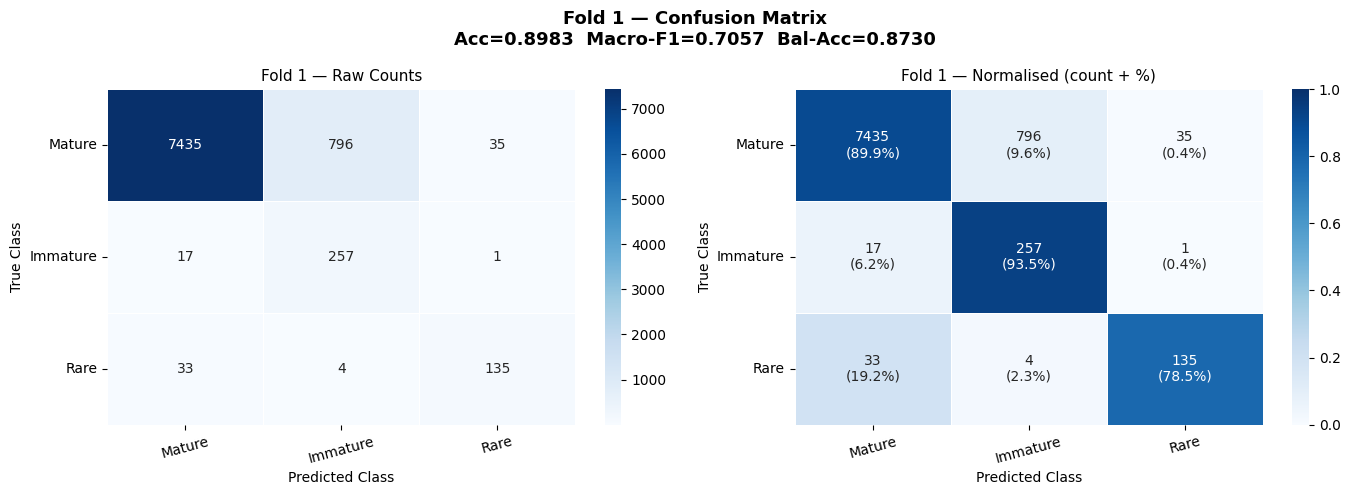

  Confusion matrix saved → /content/drive/MyDrive/wbc/checkpoints/fold1_confusion_matrix.png

--- FOLD 2/3 ---
  train=17,426  val=8,713
  Criterion alpha (class weights): [ 0.35 10.54 16.93]
Trainable params : 3,843 / 27,822,435
  Epoch 01/12  tr_loss=0.9994  va_loss=0.6464  tr_acc=0.6293  va_acc=0.0578  va_F1=0.1431  lr=1.0e-04  mixup=False
  Epoch 02/12  tr_loss=0.3176  va_loss=0.5259  tr_acc=0.6852  va_acc=0.1359  va_F1=0.2179  lr=1.0e-04  mixup=False
All layers unfrozen — 27,822,435 trainable params
  → Backbone unfrozen | backbone_lr=5e-06 | head_lr=1e-04
  Epoch 03/12  tr_loss=0.1684  va_loss=0.2782  tr_acc=0.7589  va_acc=0.4489  va_F1=0.3186  lr=4.9e-06  mixup=True
  Epoch 04/12  tr_loss=0.1117  va_loss=0.5206  tr_acc=0.8159  va_acc=0.4769  va_F1=0.4419  lr=4.5e-06  mixup=True
  Epoch 05/12  tr_loss=0.0956  va_loss=0.2430  tr_acc=0.8491  va_acc=0.5397  va_F1=0.3667  lr=4.0e-06  mixup=True
  Epoch 06/12  tr_loss=0.0961  va_loss=0.1968  tr_acc=0.8551  va_acc=0.7196  va_F1=0.5524 

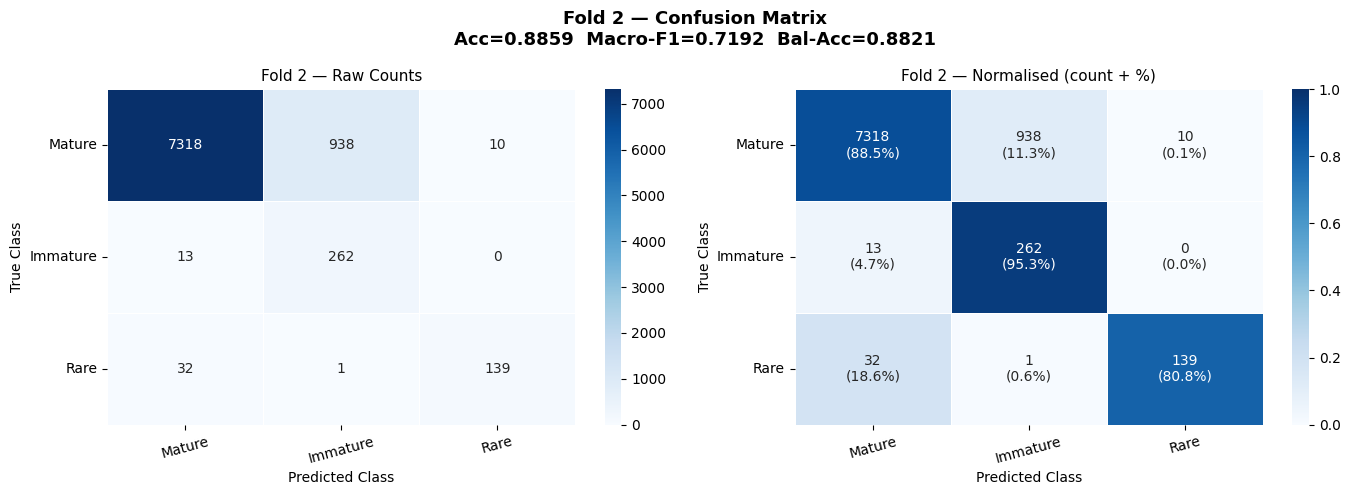

  Confusion matrix saved → /content/drive/MyDrive/wbc/checkpoints/fold2_confusion_matrix.png

--- FOLD 3/3 ---
  train=17,426  val=8,713
  Criterion alpha (class weights): [ 0.35 10.56 16.89]
Trainable params : 3,843 / 27,822,435
  Epoch 01/12  tr_loss=0.7195  va_loss=0.6032  tr_acc=0.6409  va_acc=0.0675  va_F1=0.1354  lr=1.0e-04  mixup=False
  Epoch 02/12  tr_loss=0.3031  va_loss=0.5208  tr_acc=0.7017  va_acc=0.1903  va_F1=0.2353  lr=1.0e-04  mixup=False
All layers unfrozen — 27,822,435 trainable params
  → Backbone unfrozen | backbone_lr=5e-06 | head_lr=1e-04
  Epoch 03/12  tr_loss=0.1624  va_loss=0.3343  tr_acc=0.7669  va_acc=0.3807  va_F1=0.3059  lr=4.9e-06  mixup=True
  Epoch 04/12  tr_loss=0.1181  va_loss=0.3357  tr_acc=0.8117  va_acc=0.5330  va_F1=0.4989  lr=4.5e-06  mixup=True
  Epoch 05/12  tr_loss=0.0906  va_loss=0.2488  tr_acc=0.8442  va_acc=0.8519  va_F1=0.6529  lr=4.0e-06  mixup=True
  Epoch 06/12  tr_loss=0.0920  va_loss=0.3427  tr_acc=0.8536  va_acc=0.7359  va_F1=0.5741 

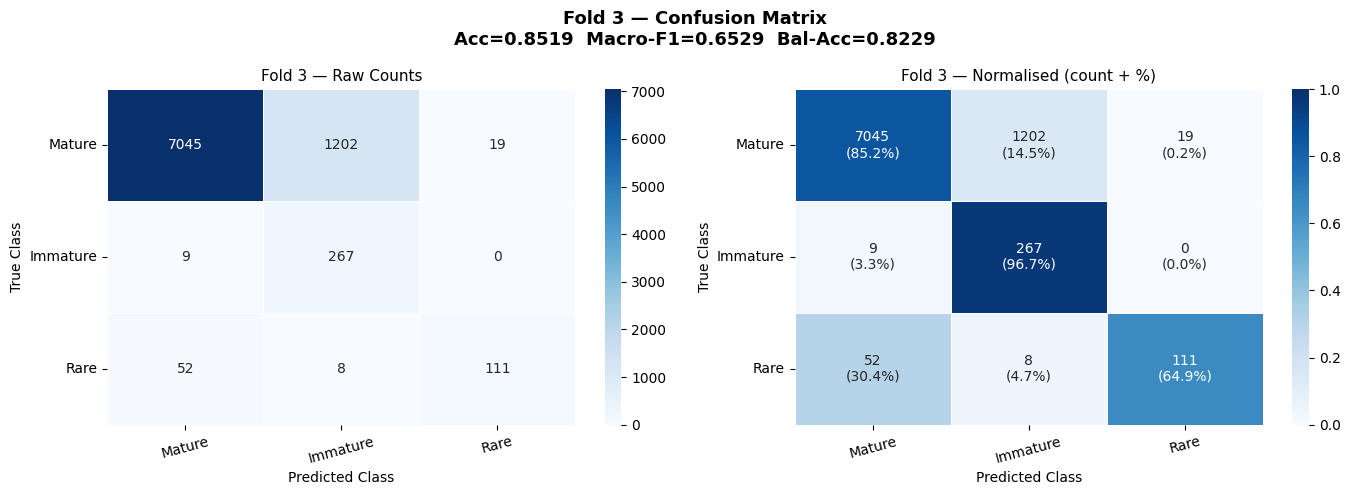

  Confusion matrix saved → /content/drive/MyDrive/wbc/checkpoints/fold3_confusion_matrix.png

  CROSS-VALIDATION COMPLETE — PER FOLD SUMMARY
  Fold        Acc   Bal-Acc    Mac-P    Mac-R   Mac-F1    Wt-F1
  ---------------------------------------------------------
  1        0.8983    0.8730   0.6753   0.8730   0.7057   0.9234
  2        0.8859    0.8821   0.7150   0.8821   0.7192   0.9167
  3        0.8519    0.8229   0.6753   0.8229   0.6529   0.8937
  ---------------------------------------------------------
  Mean     0.8787    0.8593   0.6885   0.8593   0.6926   0.9113

  Per-class OOF metrics:
  Class         Precision     Recall         F1
  --------------------------------------------
  Mature           0.9929     0.8790     0.9325
  Immature         0.2104     0.9516     0.3447
  Rare             0.8556     0.7476     0.7979

  OOF (all folds combined):
  Accuracy          : 0.8787
  Balanced Accuracy : 0.8594
  Macro Precision   : 0.6863
  Macro Recall      : 0.8594
  Macro F

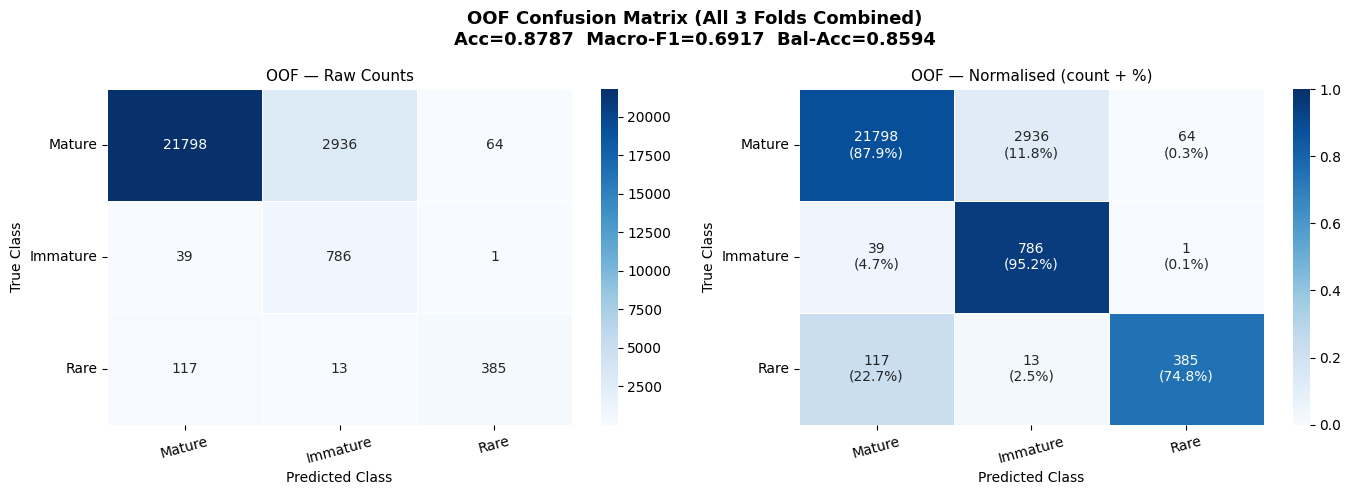


OOF confusion matrix saved → /content/drive/MyDrive/wbc/checkpoints/oof_confusion_matrix_all_folds.png


In [19]:

from sklearn.metrics import (
    classification_report, confusion_matrix,
    balanced_accuracy_score, f1_score,
    precision_score, recall_score, accuracy_score
)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np

CLASSES = CFG['classes']   # ['Mature', 'Immature', 'Rare']

# ── Combine train + val for CV (test stays completely separate) ────
trainval_df = pd.concat([train_df, val_df], ignore_index=True)
trainval_df = trainval_df.sample(frac=1, random_state=SEED).reset_index(drop=True)

skf         = StratifiedKFold(n_splits=CFG['n_folds'], shuffle=True, random_state=SEED)
oof_preds   = np.zeros(len(trainval_df), dtype=int)
oof_targets = trainval_df['label_idx'].values.astype(int)
fold_results = []

print(f"Starting {CFG['n_folds']}-fold CV on {len(trainval_df):,} images")
print("=" * 60)

for fold, (tr_idx, va_idx) in enumerate(
        skf.split(trainval_df, trainval_df['label_idx']), start=1):

    print(f"\n--- FOLD {fold}/{CFG['n_folds']} ---")
    f_tr = trainval_df.iloc[tr_idx].reset_index(drop=True)
    f_va = trainval_df.iloc[va_idx].reset_index(drop=True)
    print(f"  train={len(f_tr):,}  val={len(f_va):,}")

    # FocalLoss with inverse-freq weights from THIS fold's train set
    criterion = make_criterion(f_tr)

    tr_loader, va_loader, _ = make_loaders(f_tr, f_va, test_df)
    model = build_model(freeze_backbone=True)

    hist, ckpt_path, best_f1 = run_training(
        model, tr_loader, va_loader, criterion, fold_id=f'fold{fold}'
    )

    # Load best checkpoint and predict on OOF fold
    model.load_state_dict(torch.load(ckpt_path, map_location=device))
    _, va_acc, va_f1, va_preds, va_tgt = evaluate(model, va_loader, criterion)
    oof_preds[va_idx] = va_preds

    # ── Per-fold detailed metrics ──────────────────────────────────
    fold_acc       = accuracy_score(va_tgt, va_preds)
    fold_ba        = balanced_accuracy_score(va_tgt, va_preds)
    fold_macro_f1  = f1_score(va_tgt, va_preds, average='macro',    zero_division=0)
    fold_wt_f1     = f1_score(va_tgt, va_preds, average='weighted', zero_division=0)
    fold_macro_p   = precision_score(va_tgt, va_preds, average='macro',    zero_division=0)
    fold_macro_r   = recall_score(va_tgt, va_preds,    average='macro',    zero_division=0)
    fold_per_p     = precision_score(va_tgt, va_preds, average=None, zero_division=0, labels=[0,1,2])
    fold_per_r     = recall_score(va_tgt, va_preds,    average=None, zero_division=0, labels=[0,1,2])
    fold_per_f1    = f1_score(va_tgt, va_preds,        average=None, zero_division=0, labels=[0,1,2])

    fold_results.append({
        'fold'     : fold,
        'acc'      : fold_acc,
        'ba'       : fold_ba,
        'macro_f1' : fold_macro_f1,
        'wt_f1'    : fold_wt_f1,
        'macro_p'  : fold_macro_p,
        'macro_r'  : fold_macro_r,
        'per_p'    : fold_per_p,
        'per_r'    : fold_per_r,
        'per_f1'   : fold_per_f1,
        'preds'    : va_preds,
        'targets'  : va_tgt,
        'history'  : hist,
    })

    # ── Print fold summary ─────────────────────────────────────────
    print(f"\n  {'='*52}")
    print(f"  FOLD {fold} RESULTS")
    print(f"  {'='*52}")
    print(f"  Accuracy          : {fold_acc:.4f}")
    print(f"  Balanced Accuracy : {fold_ba:.4f}")
    print(f"  Macro Precision   : {fold_macro_p:.4f}")
    print(f"  Macro Recall      : {fold_macro_r:.4f}")
    print(f"  Macro F1          : {fold_macro_f1:.4f}")
    print(f"  Weighted F1       : {fold_wt_f1:.4f}")
    print(f"\n  Per-class breakdown:")
    print(f"  {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print(f"  {'-'*44}")
    for i, cls in enumerate(CLASSES):
        print(f"  {cls:<12} {fold_per_p[i]:>10.4f} "
              f"{fold_per_r[i]:>10.4f} {fold_per_f1[i]:>10.4f}")
    print(f"  {'='*52}")

    # ── Per-fold confusion matrix plot ─────────────────────────────
    cm      = confusion_matrix(va_tgt, va_preds, labels=[0, 1, 2])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    # Annotation: count + percentage
    annot = np.array([
        [f"{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)"
         for j in range(len(CLASSES))]
        for i in range(len(CLASSES))
    ])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f"Fold {fold} — Confusion Matrix\n"
        f"Acc={fold_acc:.4f}  Macro-F1={fold_macro_f1:.4f}  "
        f"Bal-Acc={fold_ba:.4f}",
        fontsize=13, fontweight='bold'
    )

    # Left: counts only
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=CLASSES, yticklabels=CLASSES,
        linewidths=0.5, ax=axes[0], cbar=True
    )
    axes[0].set_title(f'Fold {fold} — Raw Counts', fontsize=11)
    axes[0].set_xlabel('Predicted Class', fontsize=10)
    axes[0].set_ylabel('True Class',      fontsize=10)
    axes[0].tick_params(axis='x', rotation=15)
    axes[0].tick_params(axis='y', rotation=0)

    # Right: normalised + count+% annotation
    sns.heatmap(
        cm_norm, annot=annot, fmt='s', cmap='Blues',
        xticklabels=CLASSES, yticklabels=CLASSES,
        linewidths=0.5, ax=axes[1], cbar=True,
        vmin=0, vmax=1
    )
    axes[1].set_title(f'Fold {fold} — Normalised (count + %)', fontsize=11)
    axes[1].set_xlabel('Predicted Class', fontsize=10)
    axes[1].set_ylabel('True Class',      fontsize=10)
    axes[1].tick_params(axis='x', rotation=15)
    axes[1].tick_params(axis='y', rotation=0)

    plt.tight_layout()
    fold_cm_path = os.path.join(CFG['save_dir'], f'fold{fold}_confusion_matrix.png')
    plt.savefig(fold_cm_path, dpi=120, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print(f"  Confusion matrix saved → {fold_cm_path}")

    # Free GPU memory between folds
    del model, tr_loader, va_loader
    torch.cuda.empty_cache()


# ══════════════════════════════════════════════════════════════════
# OOF Summary across all folds
# ══════════════════════════════════════════════════════════════════
oof_f1      = f1_score(oof_targets, oof_preds, average='macro',    zero_division=0)
oof_wt_f1   = f1_score(oof_targets, oof_preds, average='weighted', zero_division=0)
oof_ba      = balanced_accuracy_score(oof_targets, oof_preds)
oof_acc     = accuracy_score(oof_targets, oof_preds)
oof_macro_p = precision_score(oof_targets, oof_preds, average='macro',    zero_division=0)
oof_macro_r = recall_score(oof_targets, oof_preds,    average='macro',    zero_division=0)
oof_per_p   = precision_score(oof_targets, oof_preds, average=None, zero_division=0, labels=[0,1,2])
oof_per_r   = recall_score(oof_targets, oof_preds,    average=None, zero_division=0, labels=[0,1,2])
oof_per_f1  = f1_score(oof_targets, oof_preds,        average=None, zero_division=0, labels=[0,1,2])

print("\n" + "=" * 60)
print("  CROSS-VALIDATION COMPLETE — PER FOLD SUMMARY")
print("=" * 60)
print(f"  {'Fold':<6} {'Acc':>8} {'Bal-Acc':>9} {'Mac-P':>8} "
      f"{'Mac-R':>8} {'Mac-F1':>8} {'Wt-F1':>8}")
print(f"  {'-'*57}")
for r in fold_results:
    print(f"  {r['fold']:<6} {r['acc']:>8.4f} {r['ba']:>9.4f} "
          f"{r['macro_p']:>8.4f} {r['macro_r']:>8.4f} "
          f"{r['macro_f1']:>8.4f} {r['wt_f1']:>8.4f}")

mean_acc = np.mean([r['acc']      for r in fold_results])
mean_ba  = np.mean([r['ba']       for r in fold_results])
mean_p   = np.mean([r['macro_p']  for r in fold_results])
mean_r   = np.mean([r['macro_r']  for r in fold_results])
mean_f1  = np.mean([r['macro_f1'] for r in fold_results])
mean_wf1 = np.mean([r['wt_f1']   for r in fold_results])

print(f"  {'-'*57}")
print(f"  {'Mean':<6} {mean_acc:>8.4f} {mean_ba:>9.4f} "
      f"{mean_p:>8.4f} {mean_r:>8.4f} {mean_f1:>8.4f} {mean_wf1:>8.4f}")

print(f"\n  Per-class OOF metrics:")
print(f"  {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print(f"  {'-'*44}")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:<12} {oof_per_p[i]:>10.4f} "
          f"{oof_per_r[i]:>10.4f} {oof_per_f1[i]:>10.4f}")

print(f"\n  OOF (all folds combined):")
print(f"  Accuracy          : {oof_acc:.4f}")
print(f"  Balanced Accuracy : {oof_ba:.4f}")
print(f"  Macro Precision   : {oof_macro_p:.4f}")
print(f"  Macro Recall      : {oof_macro_r:.4f}")
print(f"  Macro F1          : {oof_f1:.4f}")
print(f"  Weighted F1       : {oof_wt_f1:.4f}")

# ── OOF Confusion Matrix (all folds combined) ──────────────────────
cm_oof      = confusion_matrix(oof_targets, oof_preds, labels=[0, 1, 2])
cm_oof_norm = cm_oof.astype(float) / cm_oof.sum(axis=1, keepdims=True)

annot_oof = np.array([
    [f"{cm_oof[i,j]}\n({cm_oof_norm[i,j]*100:.1f}%)"
     for j in range(len(CLASSES))]
    for i in range(len(CLASSES))
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    f"OOF Confusion Matrix (All {CFG['n_folds']} Folds Combined)\n"
    f"Acc={oof_acc:.4f}  Macro-F1={oof_f1:.4f}  "
    f"Bal-Acc={oof_ba:.4f}",
    fontsize=13, fontweight='bold'
)

sns.heatmap(
    cm_oof, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES,
    linewidths=0.5, ax=axes[0], cbar=True
)
axes[0].set_title('OOF — Raw Counts', fontsize=11)
axes[0].set_xlabel('Predicted Class', fontsize=10)
axes[0].set_ylabel('True Class',      fontsize=10)
axes[0].tick_params(axis='x', rotation=15)
axes[0].tick_params(axis='y', rotation=0)

sns.heatmap(
    cm_oof_norm, annot=annot_oof, fmt='s', cmap='Blues',
    xticklabels=CLASSES, yticklabels=CLASSES,
    linewidths=0.5, ax=axes[1], cbar=True,
    vmin=0, vmax=1
)
axes[1].set_title('OOF — Normalised (count + %)', fontsize=11)
axes[1].set_xlabel('Predicted Class', fontsize=10)
axes[1].set_ylabel('True Class',      fontsize=10)
axes[1].tick_params(axis='x', rotation=15)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
oof_cm_path = os.path.join(CFG['save_dir'], 'oof_confusion_matrix_all_folds.png')
plt.savefig(oof_cm_path, dpi=120, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f"\nOOF confusion matrix saved → {oof_cm_path}")
print("=" * 60)

## Cell 12 — Train final model on full train+val, evaluate on test set

In [20]:
print("Training final model on full train+val...")
print(f"train+val = {len(trainval_df):,}   test = {len(test_df):,}")
print("=" * 60)

criterion = make_criterion(trainval_df)   # FocalLoss

# Use val_df as validation during final training (for early stopping)
tr_loader_final, va_loader_final, te_loader = make_loaders(train_df, val_df, test_df)
final_model = build_model(freeze_backbone=True)

final_hist, final_ckpt, final_best_f1 = run_training(
    final_model, tr_loader_final, va_loader_final, criterion, fold_id='final'
)

# Load best checkpoint
final_model.load_state_dict(torch.load(final_ckpt, map_location=device))

# Evaluate on held-out test set (never seen during training)
te_loss, te_acc, te_f1, te_preds, te_targets = evaluate(final_model, te_loader, criterion)

print(f"\n{'='*40}")
print(f"TEST SET RESULTS")
print(f"{'='*40}")
print(f"  Loss            : {te_loss:.4f}")
print(f"  Accuracy        : {te_acc:.4f}  ({te_acc*100:.1f}%)")
print(f"  Macro-F1        : {te_f1:.4f}")
print(f"  Balanced Acc    : {balanced_accuracy_score(te_targets, te_preds):.4f}")
print()
print(classification_report(
    te_targets, te_preds,
    target_names=CFG['classes'],
    digits=4,
    zero_division=0
))


Training final model on full train+val...
train+val = 26,139   test = 4,538
  Criterion alpha (class weights): [ 0.35 10.55 16.92]
Trainable params : 3,843 / 27,822,435
  Epoch 01/12  tr_loss=0.6232  va_loss=0.5056  tr_acc=0.6583  va_acc=0.0985  va_F1=0.0738  lr=1.0e-04  mixup=False
  Epoch 02/12  tr_loss=0.2558  va_loss=0.3761  tr_acc=0.7308  va_acc=0.2376  va_F1=0.1533  lr=1.0e-04  mixup=False
All layers unfrozen — 27,822,435 trainable params
  → Backbone unfrozen | backbone_lr=5e-06 | head_lr=1e-04
  Epoch 03/12  tr_loss=0.1540  va_loss=0.2326  tr_acc=0.7759  va_acc=0.5971  va_F1=0.3110  lr=4.9e-06  mixup=True
  Epoch 04/12  tr_loss=0.1111  va_loss=0.1798  tr_acc=0.8149  va_acc=0.7298  va_F1=0.3441  lr=4.5e-06  mixup=True
  Epoch 05/12  tr_loss=0.0863  va_loss=0.1460  tr_acc=0.8544  va_acc=0.6791  va_F1=0.3610  lr=4.0e-06  mixup=True
  Epoch 06/12  tr_loss=0.0926  va_loss=0.1538  tr_acc=0.8591  va_acc=0.6634  va_F1=0.3554  lr=3.3e-06  mixup=True
  Epoch 07/12  tr_loss=0.0764  va_los

In [21]:
# ══════════════════════════════════════════════════════════════════
# IMPROVEMENT 2 — Per-Class Threshold Calibration
# ADD after Cell 12 (after TEST SET RESULTS print block)
# BEFORE Cell 13 (visualizations)
# Requires: final_model, val_df, te_loader, test_df already defined
# ══════════════════════════════════════════════════════════════════

from sklearn.metrics import f1_score
import numpy as np

print("=" * 60)
print("THRESHOLD CALIBRATION — Finding optimal per-class thresholds")
print("=" * 60)

# ── Step 1: Collect softmax probabilities on validation set ───────
final_model.eval()
va_probs_list, va_true_list = [], []

va_loader_cal = DataLoader(
    WBCDataset(val_df, mode='val'),
    batch_size  = CFG['batch_size'],
    shuffle     = False,
    num_workers = CFG['num_workers'],
    pin_memory  = CFG['pin_memory'],
)

with torch.no_grad():
    for imgs, labels in va_loader_cal:
        imgs = imgs.to(device)
        with autocast():
            logits = final_model(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        va_probs_list.append(probs)
        va_true_list.extend(labels.numpy())

va_probs = np.vstack(va_probs_list)   # (N_val, 3)
va_true  = np.array(va_true_list)     # (N_val,)

# ── Step 2: Grid-search best threshold per class ──────────────────
# Strategy: for each class C, vary its threshold t in [0.1, 0.9].
# Predict C when prob[C] >= t AND prob[C] is the max class.
# Maximise per-class F1 on val_df.

CLASSES       = CFG['classes']
best_thresh   = [0.5, 0.5, 0.5]   # default
thresh_grid   = np.arange(0.10, 0.91, 0.05)

print(f"\n{'Class':<12} {'Best Thresh':>12} {'Val F1 default':>15} {'Val F1 tuned':>13}")
print("-" * 55)

for cls_idx, cls_name in enumerate(CLASSES):
    default_preds = va_probs.argmax(axis=1)
    default_f1    = f1_score(va_true == cls_idx,
                             default_preds == cls_idx,
                             zero_division=0)
    best_f1_cls   = default_f1
    best_t        = 0.5

    for t in thresh_grid:
        # Override: predict cls_idx only when its prob exceeds threshold t
        preds_t = va_probs.argmax(axis=1).copy()
        # For samples where this class is max-prob, apply threshold
        for n in range(len(preds_t)):
            if va_probs[n, cls_idx] >= t and va_probs[n].argmax() == cls_idx:
                preds_t[n] = cls_idx
            elif va_probs[n].argmax() == cls_idx and va_probs[n, cls_idx] < t:
                # Not confident enough — predict second-best
                sorted_idx = va_probs[n].argsort()[::-1]
                preds_t[n] = sorted_idx[1]

        f1_t = f1_score(va_true == cls_idx, preds_t == cls_idx, zero_division=0)
        if f1_t > best_f1_cls:
            best_f1_cls = f1_t
            best_t      = t

    best_thresh[cls_idx] = best_t
    print(f"  {cls_name:<10} {best_t:>12.2f} {default_f1:>15.4f} {best_f1_cls:>13.4f}")

print(f"\nOptimal thresholds: Mature={best_thresh[0]:.2f}  "
      f"Immature={best_thresh[1]:.2f}  Rare={best_thresh[2]:.2f}")


# ── Step 3: Apply calibrated thresholds to test set ──────────────
te_probs_list, te_true_list = [], []

with torch.no_grad():
    for imgs, labels in te_loader:
        imgs = imgs.to(device)
        with autocast():
            logits = final_model(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        te_probs_list.append(probs)
        te_true_list.extend(labels.numpy())

te_probs = np.vstack(te_probs_list)
te_true  = np.array(te_true_list)

# Apply thresholds: highest-prob class wins UNLESS its prob < its threshold
def apply_thresholds(probs, thresholds):
    preds = []
    for row in probs:
        ranked = row.argsort()[::-1]
        chosen = ranked[0]
        if row[chosen] < thresholds[chosen]:
            # Not confident enough in top choice — try next
            for alt in ranked[1:]:
                if row[alt] >= thresholds[alt]:
                    chosen = alt
                    break
        preds.append(chosen)
    return np.array(preds)

te_preds_cal = apply_thresholds(te_probs, best_thresh)
te_preds_raw = te_probs.argmax(axis=1)

# ── Step 4: Compare results ───────────────────────────────────────
from sklearn.metrics import classification_report, balanced_accuracy_score

print("\n" + "=" * 60)
print("TEST SET — RAW (0.5 threshold) vs CALIBRATED")
print("=" * 60)

for label, preds in [("RAW (0.5 threshold)", te_preds_raw),
                     ("CALIBRATED (tuned)", te_preds_cal)]:
    mf1  = f1_score(te_true, preds, average='macro',    zero_division=0)
    ba   = balanced_accuracy_score(te_true, preds)
    acc  = (preds == te_true).mean()
    print(f"\n  {label}")
    print(f"    Accuracy        : {acc:.4f}")
    print(f"    Macro F1        : {mf1:.4f}")
    print(f"    Balanced Acc    : {ba:.4f}")
    per = f1_score(te_true, preds, average=None, zero_division=0)
    for i, c in enumerate(CLASSES):
        print(f"    F1 {c:<10} : {per[i]:.4f}")

print("\n" + classification_report(
    te_true, te_preds_cal,
    target_names=CLASSES, digits=4, zero_division=0
))

# Save calibrated thresholds
with open(f"{CFG['save_dir']}/best_thresholds.pkl", 'wb') as f:
    pickle.dump({'thresholds': best_thresh, 'classes': CLASSES}, f)
print(f"Thresholds saved → {CFG['save_dir']}/best_thresholds.pkl")

THRESHOLD CALIBRATION — Finding optimal per-class thresholds

Class         Best Thresh  Val F1 default  Val F1 tuned
-------------------------------------------------------
  Mature             0.50          0.9518        0.9518
  Immature           0.90          0.4164        0.6863
  Rare               0.50          0.3125        0.3125

Optimal thresholds: Mature=0.50  Immature=0.90  Rare=0.50

TEST SET — RAW (0.5 threshold) vs CALIBRATED

  RAW (0.5 threshold)
    Accuracy        : 0.9123
    Macro F1        : 0.5261
    Balanced Acc    : 0.6885
    F1 Mature     : 0.9527
    F1 Immature   : 0.4257
    F1 Rare       : 0.2000

  CALIBRATED (tuned)
    Accuracy        : 0.9121
    Macro F1        : 0.5259
    Balanced Acc    : 0.6884
    F1 Mature     : 0.9526
    F1 Immature   : 0.4251
    F1 Rare       : 0.2000

              precision    recall  f1-score   support

      Mature     0.9955    0.9132    0.9526      4377
    Immature     0.2736    0.9521    0.4251       146
        

## Cell 13 — Visualizations

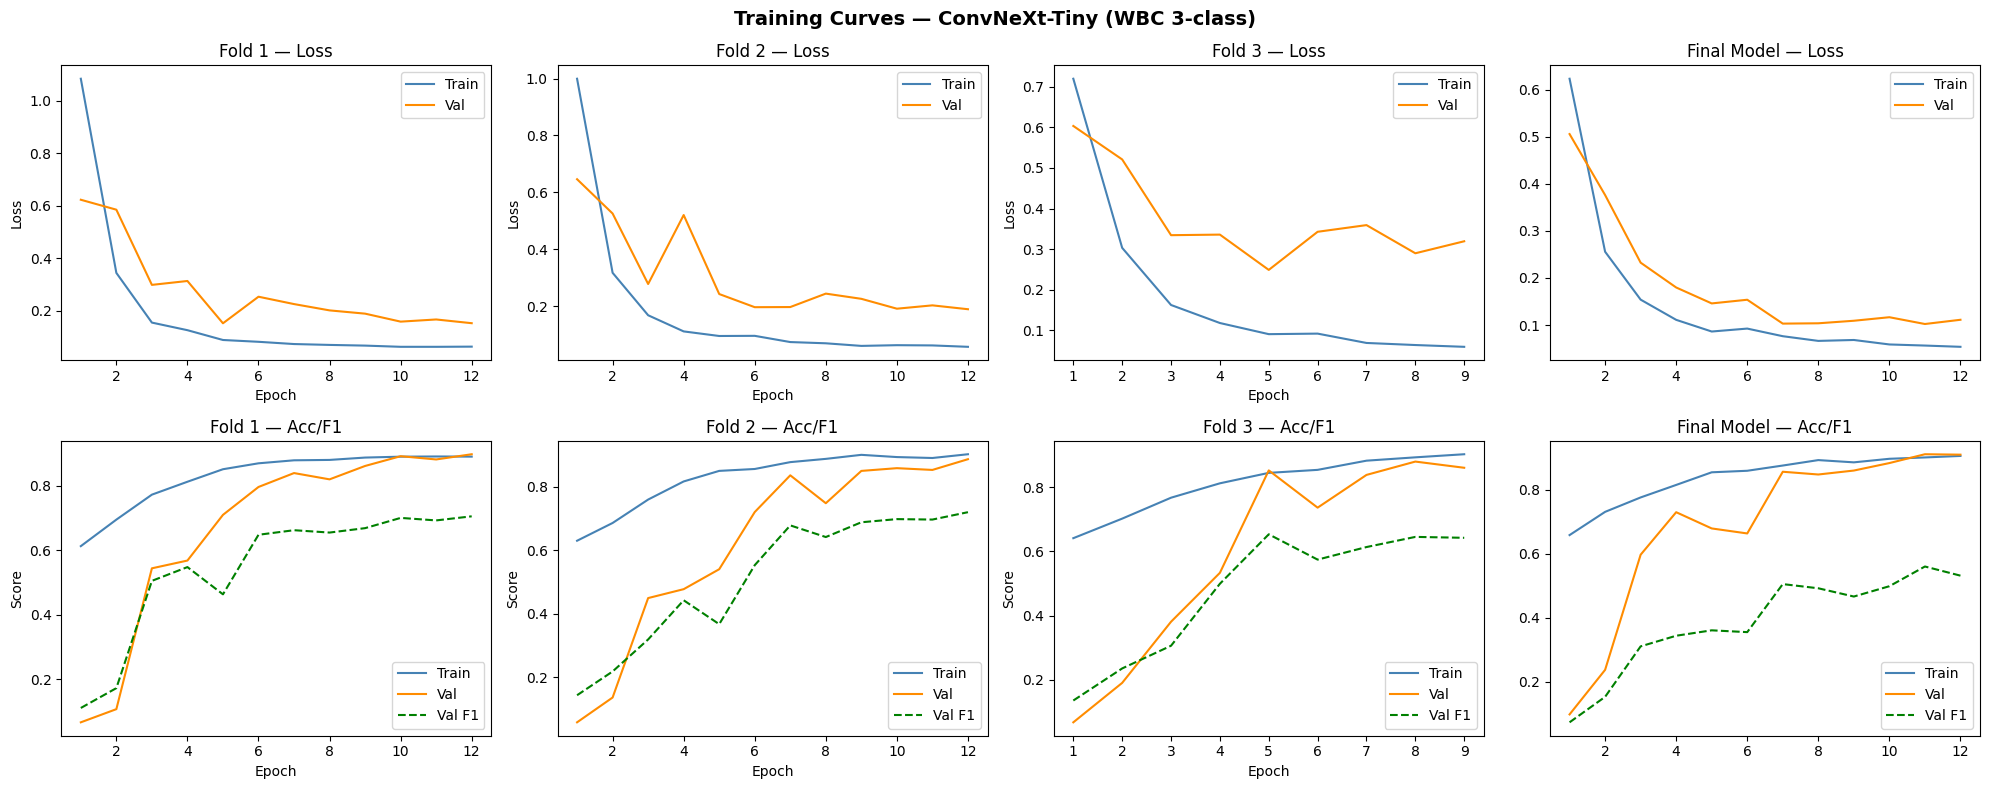

Saved: training_curves.png


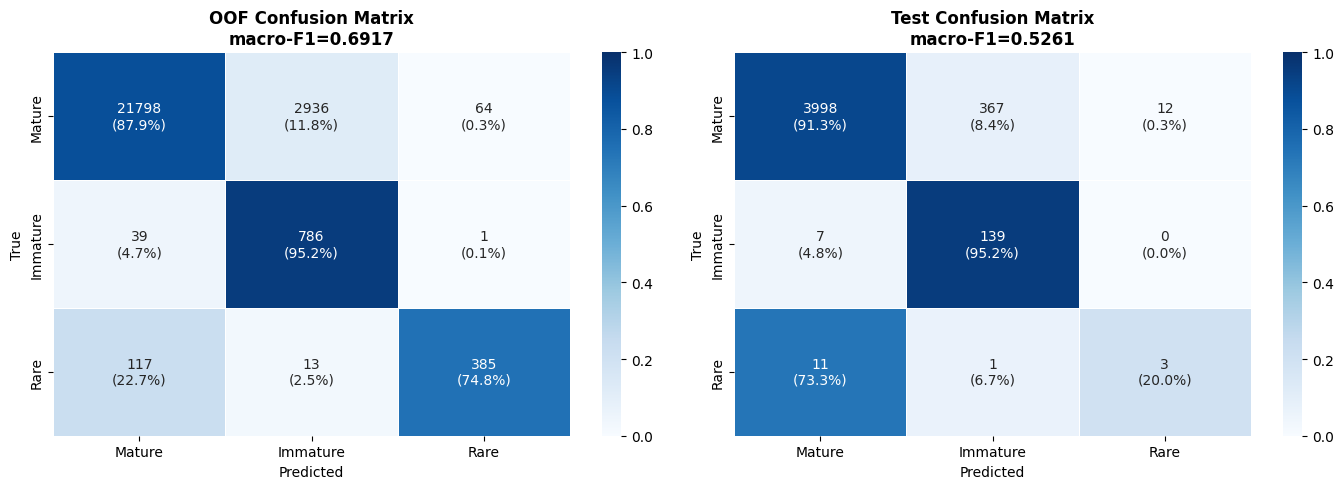

Saved: confusion_matrices.png


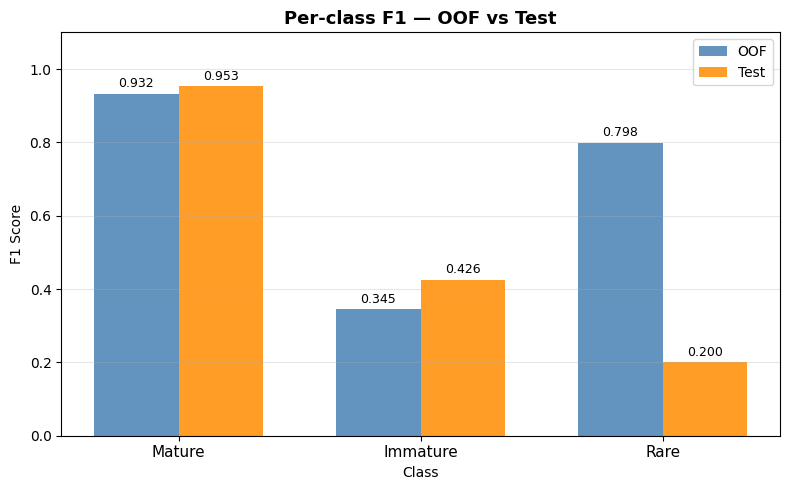

Saved: per_class_f1.png

  FINAL RESULTS SUMMARY — ConvNeXt-Tiny (3-class WBC)
  Metric                              OOF     Test
-------------------------------------------------------
  Accuracy                         0.8787   0.9123
  Macro F1                         0.6917   0.5261
  Balanced Accuracy                0.8594   0.6885
  F1 — Mature                      0.9325   0.9527
  F1 — Immature                    0.3447   0.4257
  F1 — Rare                        0.7979   0.2000

  All plots saved to: /content/drive/MyDrive/wbc/checkpoints/


In [22]:
CLASSES = CFG['classes']
os.makedirs(CFG['save_dir'], exist_ok=True)

# ── 1. Loss & accuracy curves (all folds + final) ──────────────────────────
n_folds = len(fold_results)
fig, axes = plt.subplots(2, n_folds+1, figsize=(5*(n_folds+1), 8))
fig.suptitle('Training Curves — ConvNeXt-Tiny (WBC 3-class)', fontsize=14, fontweight='bold')

for i, r in enumerate(fold_results):
    h = r['history']
    ep = range(1, len(h['tr_loss'])+1)
    axes[0,i].plot(ep, h['tr_loss'], label='Train', color='steelblue')
    axes[0,i].plot(ep, h['va_loss'], label='Val',   color='darkorange')
    axes[0,i].set_title(f"Fold {r['fold']} — Loss"); axes[0,i].legend()
    axes[0,i].set_xlabel('Epoch'); axes[0,i].set_ylabel('Loss')

    axes[1,i].plot(ep, h['tr_acc'], label='Train', color='steelblue')
    axes[1,i].plot(ep, h['va_acc'], label='Val',   color='darkorange')
    axes[1,i].plot(ep, h['va_f1'],  label='Val F1',color='green', linestyle='--')
    axes[1,i].set_title(f"Fold {r['fold']} — Acc/F1"); axes[1,i].legend()
    axes[1,i].set_xlabel('Epoch'); axes[1,i].set_ylabel('Score')

# Final model curves
h = final_hist; ep = range(1, len(h['tr_loss'])+1)
axes[0,-1].plot(ep, h['tr_loss'], color='steelblue', label='Train')
axes[0,-1].plot(ep, h['va_loss'], color='darkorange', label='Val')
axes[0,-1].set_title('Final Model — Loss'); axes[0,-1].legend()
axes[1,-1].plot(ep, h['tr_acc'], color='steelblue', label='Train')
axes[1,-1].plot(ep, h['va_acc'], color='darkorange', label='Val')
axes[1,-1].plot(ep, h['va_f1'],  color='green', linestyle='--', label='Val F1')
axes[1,-1].set_title('Final Model — Acc/F1'); axes[1,-1].legend()

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/training_curves.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: training_curves.png")

# ── 2. OOF confusion matrix ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (preds, targets, title) in zip(axes, [
    (oof_preds, oof_targets, f'OOF Confusion Matrix\nmacro-F1={oof_f1:.4f}'),
    (te_preds,  te_targets,  f'Test Confusion Matrix\nmacro-F1={te_f1:.4f}'),
]):
    cm = confusion_matrix(targets, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    annot = np.array([[f'{cm[i,j]}\n({cm_norm[i,j]*100:.1f}%)'
                       for j in range(len(CLASSES))]
                      for i in range(len(CLASSES))])
    sns.heatmap(cm_norm, annot=annot, fmt='s', cmap='Blues',
                xticklabels=CLASSES, yticklabels=CLASSES,
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/confusion_matrices.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: confusion_matrices.png")

from sklearn.metrics import f1_score as f1s

fig, ax = plt.subplots(figsize=(8,5))
oof_per = f1s(oof_targets, oof_preds, average=None, zero_division=0)
te_per  = f1s(te_targets,  te_preds,  average=None, zero_division=0)
x = np.arange(len(CLASSES)); w = 0.35
bars1 = ax.bar(x-w/2, oof_per, w, label='OOF',  color='steelblue', alpha=0.85)
bars2 = ax.bar(x+w/2, te_per,  w, label='Test', color='darkorange', alpha=0.85)
for bar in bars1+bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, fontsize=11)
ax.set_ylim(0,1.1); ax.set_ylabel('F1 Score'); ax.set_xlabel('Class')
ax.set_title('Per-class F1 — OOF vs Test', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['save_dir']}/per_class_f1.png", dpi=120, bbox_inches='tight')
plt.show()
print("Saved: per_class_f1.png")


print("\n" + "="*55)
print("  FINAL RESULTS SUMMARY — ConvNeXt-Tiny (3-class WBC)")
print("="*55)
print(f"  {'Metric':<30} {'OOF':>8} {'Test':>8}")
print("-"*55)
print(f"  {'Accuracy':<30} {sum(oof_preds==oof_targets)/len(oof_targets):>8.4f} {te_acc:>8.4f}")
print(f"  {'Macro F1':<30} {oof_f1:>8.4f} {te_f1:>8.4f}")
print(f"  {'Balanced Accuracy':<30} {oof_ba:>8.4f} {balanced_accuracy_score(te_targets,te_preds):>8.4f}")
for i,c in enumerate(CLASSES):
    print(f"  {'F1 — '+c:<30} {oof_per[i]:>8.4f} {te_per[i]:>8.4f}")
print("="*55)
print(f"\n  All plots saved to: {CFG['save_dir']}/")


## Cell 14 — Save final model & results to Drive

In [23]:
print(fold_results)

[{'fold': 1, 'acc': 0.8983128658326638, 'ba': np.float64(0.8729656248278905), 'macro_f1': 0.7057083136366732, 'wt_f1': 0.9233525060320713, 'macro_p': 0.675311540828563, 'macro_r': 0.8729656248278905, 'per_p': array([0.99331997, 0.24314096, 0.78947368]), 'per_r': array([0.8994677 , 0.93454545, 0.78488372]), 'per_f1': array([0.94406704, 0.38588589, 0.78717201]), 'preds': [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 

In [24]:

import pickle

# Save final model weights
torch.save(
    final_model.state_dict(),
    f"{CFG['save_dir']}/convnext_final.pth"
)

# Check what keys fold_results actually has
print("fold_results keys:", fold_results[0].keys() if fold_results else "empty")

# Build results dict safely
results = {
    'model'    : 'ConvNeXt-Tiny',
    'test_f1'  : float(te_f1),
    'test_acc' : float(te_acc),
    'test_ba'  : float(balanced_accuracy_score(te_targets, te_preds)),
    'oof_f1'   : float(oof_f1),
    'oof_ba'   : float(oof_ba),
    'oof_per_class'  : {c: float(oof_per[i]) for i, c in enumerate(CLASSES)},
    'test_per_class' : {c: float(te_per[i])  for i, c in enumerate(CLASSES)},
    'fold_results'   : fold_results,   # save as-is, no key extraction
    'mean_cv_f1'     : float(mean_f1),
    'mean_cv_acc'    : float(mean_acc),
}

with open(f"{CFG['save_dir']}/convnext_results.pkl", 'wb') as f:
    pickle.dump(results, f)

print("Saved to Drive:")
for fname in ['convnext_final.pth', 'convnext_results.pkl',
              'training_curves.png', 'confusion_matrices.png',
              'per_class_f1.png']:
    fpath = f"{CFG['save_dir']}/{fname}"
    if os.path.exists(fpath):
        kb = os.path.getsize(fpath) / 1024
        print(f"  ✓ {fname}  ({kb:.0f} KB)")
    else:
        print(f"  ✗ {fname}  (NOT FOUND)")

print("\nAll done! Session can now disconnect safely.")

fold_results keys: dict_keys(['fold', 'acc', 'ba', 'macro_f1', 'wt_f1', 'macro_p', 'macro_r', 'per_p', 'per_r', 'per_f1', 'preds', 'targets', 'history'])
Saved to Drive:
  ✓ convnext_final.pth  (108751 KB)
  ✓ convnext_results.pkl  (105 KB)
  ✓ training_curves.png  (197 KB)
  ✓ confusion_matrices.png  (70 KB)
  ✓ per_class_f1.png  (29 KB)

All done! Session can now disconnect safely.


In [ ]:

# ==========================================================
# EXPERIMENT-1 : DECOUPLED TRAINING
# ==========================================================

def decoupled_training_stage(
    model,
    tr_loader,
    va_loader,
    criterion,
    fold_id='fold'
):

    print("\nSTARTING DECOUPLED TRAINING")

    # Freeze backbone
    for name, param in model.named_parameters():

        if 'head' in name:
            param.requires_grad = True
        else:
            param.requires_grad = False

    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CFG['decoupled_lr'],
        weight_decay=CFG['weight_decay']
    )

    scaler = GradScaler()

    best_f1 = 0

    save_path = (
        f"{CFG['save_dir']}/"
        f"{fold_id}_decoupled_best.pth"
    )

    for epoch in range(1, CFG['decoupled_epochs'] + 1):

        tr_loss, tr_acc = train_one_epoch(
            model,
            tr_loader,
            optimizer,
            criterion,
            scaler,
            use_mixup=False
        )

        va_loss, va_acc, va_f1, preds, targets = evaluate(
            model,
            va_loader,
            criterion
        )

        bal_acc = balanced_accuracy_score(
            targets,
            preds
        )

        weighted_f1 = f1_score(
            targets,
            preds,
            average='weighted'
        )

        print(
            f"[DECOUPLED] "
            f"Epoch {epoch:02d}/{CFG['decoupled_epochs']} | "
            f"tr_loss={tr_loss:.4f} | "
            f"va_loss={va_loss:.4f} | "
            f"acc={va_acc:.4f} | "
            f"bal_acc={bal_acc:.4f} | "
            f"macro_f1={va_f1:.4f} | "
            f"weighted_f1={weighted_f1:.4f}"
        )

        if va_f1 > best_f1:

            best_f1 = va_f1

            torch.save(
                model.state_dict(),
                save_path
            )

            print("BEST DECOUPLED MODEL SAVED")

    return save_path



# Experiment-1 Evaluation Metrics

Compare:
- Macro F1
- Balanced Accuracy
- Rare Recall
- Rare Precision
- Confusion Matrix

Main observations:
- Rare class stability
- Mature→Immature confusion
- Rare false negatives
- Fold variance
- Weighted F1 vs Macro F1
- Effect of decoupled head tuning
